In [113]:
# ~~~~ Imports ~~~~
import os, random, glob
import math
import pickle, json
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
# from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, dirichlet
from scipy.signal import savgol_filter
from sklearn.isotonic import IsotonicRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from openTSNE import TSNE as oTSNE

# ~~~~ Environment setup ~~~~
device = torch.device('cpu')
print(f"Using device: {device}")

SEED = 29
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

from VAE_model_architectures import *

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

set_seed(SEED)

run_where = 'local'

# ~~~~ Configuration ~~~~
class Config:
    if run_where == 'great-lakes':
        BASE_DIR = "/nfs/turbo/umms-kaczoro/u19-shared/vae-HC-PFC/14mon_ADBXD_joined/"
        MODEL_PATH = os.path.join(BASE_DIR, "seed_model/C-GMVAE_SEED_38/saved_model_epoch20000.pth")
        GENE_CSV_PATH = "/nfs/turbo/umms-kaczoro/u19-shared/vae-HC-PFC/14mon_ADBXD_joined/input_datasets/hc_pfc_combined_rp_nor.csv"
        CFM_CSV_PATH  = "/nfs/turbo/umms-kaczoro/u19-shared/vae-HC-PFC/14mon_ADBXD_joined/input_datasets/CFC_CFM_residual_Bins_all_Strains.csv"
        LATENT_SPACE_CSV = os.path.join(BASE_DIR, "seed_model/C-GMVAE_SEED_38/latent_variables_epoch20000.csv")
        RECONS_DATA_CSV  = os.path.join(BASE_DIR, "seed_model/C-GMVAE_SEED_38/recons_cfm.csv")

    elif run_where == 'local':
        BASE_DIR = "/home/nghayes/latent-space-trajectories/"
        MODEL_PATH = os.path.join(BASE_DIR, "saved_model_epoch20000.pth")
        GENE_CSV_PATH = os.path.join(BASE_DIR, "hc_pfc_combined_rp_nor.csv")
        CFM_CSV_PATH  = os.path.join(BASE_DIR, "CFC_CFM_residual_Bins_all_Strains.csv")
        LATENT_SPACE_CSV = os.path.join(BASE_DIR, "latent_variables_epoch20000.csv")
        RECONS_DATA_CSV  = os.path.join(BASE_DIR, "recons_cfm.csv")

    GENE_COUNT = 4963
    D_in = D_out = GENE_COUNT
    LATENT_DIM = 10
    H1, H2, H3 = 128, 64, 32

    NUM_INTERPOLATION_STEPS = 24
    DENSITY_WEIGHTS = [0.1, 0.2, 0.3]
    DEFAULT_DENSITY_WEIGHT = 0.1
    NUM_PAIRS = 10
    KNN = 5
    

Using device: cpu


## Checking data

In [2]:
expected_hash = '64fed1ca5af52069568bb6064c4c51ada6aa544faea7240dd975c89902c4a1d8'
my_hash = '64fed1ca5af52069568bb6064c4c51ada6aa544faea7240dd975c89902c4a1d8'

expected_hash == my_hash

True

In [3]:
pd.read_csv(Config.LATENT_SPACE_CSV, index_col=0).iloc[:,-15:]

,LV8,LV9,LV10,barcode,subclass,cell_type,SCBID,MouseID,Age,Strain,Genotype,CFM_14_5_snRNA,14-6-residual,14-6-Bin,region
0,1.312754,5.479063,10.920240,CK19047_AGAAATGTCTGTAAGC-1,006 L4/5 IT CTX Glut,Glut,CK19047,1583,14,33,5,1.047481,0.133901,2,PFC
1,-9.226448,-8.665678,-4.734122,CK19032_GCTTGGGCATATGAAG-1,061 STR D1 Gaba,Gaba,CK19032,1596,14,124,5,1.231932,0.738297,3,PFC
2,14.726957,23.734491,29.096786,CK19107_CTACCTGTCGGTGAAG-1,319 Astro-TE NN,Astrocytes,CK19107,1583,14,33,5,1.047481,0.383536,2,HC
3,-5.782712,-5.136093,-1.035175,CK19119_ATGAAAGCATGCCGGT-1,002 IT EP-CLA Glut,glut,CK19119,5696,14,B6,5,-0.825919,1.040817,3,HC
4,28.219280,36.607440,41.267610,CK19120_TCGAACAAGCCTGGAA-1,037 DG Glut,glut,CK19120,1532,14,65,5,0.708210,-1.314067,0,HC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-5.416104,-4.710186,-0.721344,CK19111_CCTATCGGTGACTCGC-1,327 Oligo NN,Oligo,CK19111,1272,14,53,5,0.263749,0.660932,3,PFC
56646,31.937830,40.201540,44.993100,CK19033_GGGAAGTAGCTGACTT-1,070 LSX Prdm12 Slit2 Gaba,Gaba,CK19033,1966,14,83,5,-0.974072,-0.989843,0,PFC
56647,15.751303,24.399230,29.637558,CK19059_CCGATGGGTAGTGCGA-1,319 Astro-TE NN,Astrocytes,CK19059,2433,14,113,5,0.550426,-0.111132,2,HC
56648,-5.845601,-5.259646,-1.332067,CK19078_TGCATCCCACGCCACA-1,037 DG Glut,glut,CK19078,1596,14,124,5,1.231932,1.277393,3,HC


In [4]:
print(pd.read_csv(Config.CFM_CSV_PATH, index_col=0))

   Strain  CFM_14_5_snRNA  14-6-residual  14-6-Bin
0      83           29.38      -0.989843         0
1     161           20.58      -0.974140         0
2      65           52.09      -0.928484         0
3      50           28.04      -0.627820         1
4      D2           24.44      -0.552464         1
5      28           39.47      -0.460462         1
6      39           41.56      -0.234839         2
7     113           49.96      -0.148236         2
8      33           56.67       0.133901         2
9      B6           31.38       0.583512         3
10     99           53.16       0.585682         3
11     53           46.09       0.660932         3
12    124           59.16       0.738297         3
13     66           51.38       0.783511         3


In [5]:
# pd.read_csv(Config.GENE_CSV_PATH, index_col=0).iloc[:,-20:]
# pd.read_csv(Config.GENE_CSV_PATH, index_col=0).iloc[:,:20]

df_gene = pd.read_csv(Config.GENE_CSV_PATH, index_col=0)
df_gene.iloc[:,-20:]


/tmp/ipykernel_4652/19781639.py:4: DtypeWarning: Columns (0: Genotype) have mixed types. Specify dtype option on import or set low_memory=False.
  df_gene = pd.read_csv(Config.GENE_CSV_PATH, index_col=0)


,4955,4956,4957,4958,4959,4960,4961,4962,barcode,subclass,cell_type,SCBID,MouseID,Age,Strain,Genotype,CFM_14_5_snRNA,14-6-residual,14-6-Bin,region
0,-0.931973,-0.065189,0.166368,-0.101187,-1.280182,-1.942002,0.266360,0.602739,CK19012_AAACGCTTCCTCAGGG-1,319 Astro-TE NN,Astrocytes,CK19012,1576,14,D2,5,24.44,-0.673075,1,HC
1,-0.002892,-0.056767,0.753536,-1.075334,0.500151,-0.638557,-1.621977,-0.228546,CK19012_AAAGGATGTCAGACTT-1,319 Astro-TE NN,Astrocytes,CK19012,1576,14,D2,5,24.44,-0.673075,1,HC
2,0.714224,0.300153,-0.606640,1.640799,0.278409,-1.240707,-0.382348,-0.137175,CK19012_AAAGTCCGTGGTTTAC-1,319 Astro-TE NN,Astrocytes,CK19012,1576,14,D2,5,24.44,-0.673075,1,HC
3,0.158629,0.002027,0.249486,-0.539993,-0.049498,1.223141,-0.755811,-0.306300,CK19012_AAATGGACAGAGCCCT-1,319 Astro-TE NN,Astrocytes,CK19012,1576,14,D2,5,24.44,-0.673075,1,HC
4,0.658266,-0.140407,-0.552071,-0.286781,-1.387746,-0.187427,-0.201739,-0.311040,CK19012_AACAAAGAGACCAGAC-1,319 Astro-TE NN,Astrocytes,CK19012,1576,14,D2,5,24.44,-0.673075,1,HC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-0.616309,0.678618,0.917301,-0.133303,-0.719628,-0.309752,-2.340278,0.946940,CK19063_TTTGACTAGCCGGATA-1,327 Oligo NN,Oligo,CK19063,2433,14,113,5,49.96,-0.148236,2,PFC
56646,-0.319459,0.093052,-0.216758,-0.347267,0.432248,-0.201304,0.427027,0.081553,CK19063_TTTGACTAGGGTTTCT-1,327 Oligo NN,Oligo,CK19063,2433,14,113,5,49.96,-0.148236,2,PFC
56647,-0.312415,-0.755265,0.741483,-0.394956,0.465602,-0.300544,-0.048364,0.496638,CK19063_TTTGATCCACCCTATC-1,327 Oligo NN,Oligo,CK19063,2433,14,113,5,49.96,-0.148236,2,PFC
56648,0.352032,0.110741,1.286447,-0.674719,0.495195,-0.570544,-0.124216,-0.241268,CK19063_TTTGGTTAGTCCGTCG-1,327 Oligo NN,Oligo,CK19063,2433,14,113,5,49.96,-0.148236,2,PFC


In [6]:
# df_strain = df_gene['MouseID', 'Age', 'Strain', 'Genotype', 'CFM_14_5_snRNA', '14-6-residual', '14-6-Bin', 'region']

df_strain = df_gene.iloc[:,-8:]

df_strain

,MouseID,Age,Strain,Genotype,CFM_14_5_snRNA,14-6-residual,14-6-Bin,region
0,1576,14,D2,5,24.44,-0.673075,1,HC
1,1576,14,D2,5,24.44,-0.673075,1,HC
2,1576,14,D2,5,24.44,-0.673075,1,HC
3,1576,14,D2,5,24.44,-0.673075,1,HC
4,1576,14,D2,5,24.44,-0.673075,1,HC
...,...,...,...,...,...,...,...,...
56645,2433,14,113,5,49.96,-0.148236,2,PFC
56646,2433,14,113,5,49.96,-0.148236,2,PFC
56647,2433,14,113,5,49.96,-0.148236,2,PFC
56648,2433,14,113,5,49.96,-0.148236,2,PFC


In [7]:
df_strain[df_strain['MouseID']==1532]

,MouseID,Age,Strain,Genotype,CFM_14_5_snRNA,14-6-residual,14-6-Bin,region
1424,1532,14,65,5,52.09,-1.314067,0,HC
1425,1532,14,65,5,52.09,-1.314067,0,HC
1426,1532,14,65,5,52.09,-1.314067,0,HC
1427,1532,14,65,5,52.09,-1.314067,0,HC
1428,1532,14,65,5,52.09,-1.314067,0,HC
...,...,...,...,...,...,...,...,...
55172,1532,14,65,5,52.09,-0.928484,0,PFC
55173,1532,14,65,5,52.09,-0.928484,0,PFC
55174,1532,14,65,5,52.09,-0.928484,0,PFC
55175,1532,14,65,5,52.09,-0.928484,0,PFC


In [8]:
# pd.read_csv(Config.RECONS_DATA_CSV, index_col=0)
df_recons = pd.read_csv(Config.RECONS_DATA_CSV, index_col=0)
# df_recons['epoch'][1189648].dtype
print(df_recons.loc[df_recons['epoch'] ==20000])
print(df_recons['epoch'].unique())

              cfm  epoch Strain
1133000  1.048495  20000     33
1133001  1.236806  20000    124
1133002  1.044764  20000     33
1133003 -0.825561  20000     B6
1133004  0.690024  20000     65
...           ...    ...    ...
1189645  0.267969  20000     53
1189646 -0.972245  20000     83
1189647  0.547159  20000    113
1189648  1.229240  20000    124
1189649  0.542213  20000    113

[56650 rows x 3 columns]
['Original' '1000' '2000' 2000 3000 4000 5000 6000 7000 8000 9000 10000
 11000 12000 13000 14000 15000 16000 17000 18000 19000 20000]


/tmp/ipykernel_4652/1778624224.py:2: DtypeWarning: Columns (0: Strain) have mixed types. Specify dtype option on import or set low_memory=False.
  df_recons = pd.read_csv(Config.RECONS_DATA_CSV, index_col=0)


## Functions for perpendicular projection

Needed for checking distance from trajectory points to target axis

In [9]:
def line_coordinates_euclidean(A, B, P):
    # A: starting point of PP axis
    # B: ending point of PP axis
    # P: point to project
    # output: point along the line (10-D coordinates), signed distance (will be PP)

    A = np.array(A)
    B = np.array(B)
    P = np.array(P)

    u_hat = (B - A) / np.linalg.norm(B - A)  # Unit direction vector from A to B
    s = np.dot(P - A, u_hat)                # Signed distance from A
    P_proj = A + s * u_hat                  # Projected point on the line

    return P_proj, s

In [10]:
def perpendicular_projection(A, B, P):
    # A: starting point of target direction axis
    # B: ending point of target direction axis
    # P: point to project (trajectory point)
    # output: perpendicular projection vector, distance from trajectory point to axis

    A = np.array(A)
    B = np.array(B)
    P = np.array(P)

    P_proj, s = line_coordinates_euclidean(A, B, P)
    perp_proj = P - P_proj
    perp_proj_dist = np.linalg.norm(P - P_proj)

    return perp_proj, perp_proj_dist

## Loading data and models

In [11]:
# ~~~~ Data Loading ~~~~
class MouseGeneDataset(Dataset):
    def __init__(self, df, dim_count=4842, device='cpu'): 
        self.dim_count = dim_count
        self.device = device
        self.x, self.R_S_label, self.cfm = self._process(df)
        self.len = self.x.shape[0]

    def _standardize(self, array):
        return (array - np.mean(array)) / np.std(array)

    def _process(self, df):
        #print(df.columns[-20:])
        x = df.iloc[:, :self.dim_count].values.astype('float32')
        R_S_label = df['14-6-Bin'].values
        cfm = self._standardize(df['14-6-residual'].values)

        return (
            torch.tensor(x).to(self.device),
            torch.tensor(R_S_label).to(self.device),
            torch.tensor(cfm).to(self.device)
        )

    def __getitem__(self, index):
        return self.x[index], self.R_S_label[index], self.cfm[index]

    def __len__(self):
        return self.len


_g = torch.Generator().manual_seed(SEED)

def load_mouse_gene_data(path_gene_csv, path_cfm_csv, dim_count=4842, device='cpu',
                         batch_size=512, shuffle=False, generator=_g):
    df = pd.read_csv(path_gene_csv, index_col=0, dtype={'Strain': str})
    print("Last 20 column names:"); print(df.columns[-20:])
    df = df.sample(frac=1, random_state=42)
    dataset = MouseGeneDataset(df, dim_count=dim_count, device=device)

    def _seed_worker(worker_id):
        worker_seed = SEED + worker_id
        np.random.seed(worker_seed); random.seed(worker_seed); torch.manual_seed(worker_seed)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                        num_workers=0, worker_init_fn=_seed_worker, generator=generator)
    return dataloader, dataset

dataloader, train_set = load_mouse_gene_data(
    path_gene_csv=Config.GENE_CSV_PATH,
    path_cfm_csv=Config.CFM_CSV_PATH,
    dim_count=Config.GENE_COUNT,
    device=device,
    batch_size=512,
    generator=_g)

print("Total samples in dataset:", len(train_set))
print("Shape of one data point:", train_set[0][0].shape)
print("Label of first sample (R/S):", train_set[0][1].item())
print("CFM of first sample:", train_set[0][2].item())

# ~~~~ Model Setup ~~~~

class Autoencoder_CGMVAE(nn.Module):
    #C-GMVAE VAE with GMM prior and conditional layer
    def __init__(self, D_in, D_out, H1=128, H2=64, H3=32, dim_code=10, num_gaussian = 4):
        #Encoder
        super(Autoencoder_CGMVAE, self).__init__()
        self.dim_code = dim_code
        self.num_gaussian = num_gaussian
        self.label = nn.Embedding(num_gaussian, 1)
        self.encoder1 = nn.Sequential(
            nn.Linear(D_in+2, H1),
            nn.BatchNorm1d(H1),
            nn.Sigmoid(),
            nn.Linear(H1,H2),
            nn.BatchNorm1d(H2),
            nn.Sigmoid(),
            nn.Linear(H2,H3),
            nn.BatchNorm1d(H3),
            nn.Sigmoid())
    
        self.mu = nn.Sequential(nn.Linear(H3, out_features = num_gaussian*dim_code))
                            
        self.logsigma = nn.Sequential(nn.Linear(H3, out_features = num_gaussian*dim_code))
        
        self.decoder = nn.Sequential(
            nn.Linear(dim_code+1, H3),
            nn.Sigmoid(),
            nn.BatchNorm1d(H3),
            nn.Linear(H3,H2),
            nn.Sigmoid(),
            nn.BatchNorm1d(H2),
            nn.Linear(H2,H1),
            nn.Sigmoid(),
            nn.BatchNorm1d(H1),
            nn.Linear(H1,D_out+1),
            nn.Sigmoid(),
            nn.BatchNorm1d(D_out+1))
        
    def gaussian_sampler(self, mu, logsigma, y):
        y = y.long().view(-1)
        batch_size = y.shape[0]
        mu_k = mu[torch.arange(batch_size), y]  
        sigma_k = torch.exp(0.5 * logsigma[torch.arange(batch_size), y])
        eps = torch.randn_like(sigma_k)
        z = mu_k + eps * sigma_k
        return mu_k, sigma_k, z
        
    def encode(self, x, y, cfm):
        cfm = cfm.view(cfm.size(0),1)
        if x.dtype != cfm.dtype:
            cfm = cfm.to(x.dtype)
        x = torch.cat((x, cfm), dim=1)
        y_emb = self.label(y)
        y_emb = y_emb.view(y_emb.size(0),1)
        x = torch.cat((x, y_emb), dim=1)
        x = self.encoder1(x)
        mu, logsigma = self.mu(x).view(-1, self.num_gaussian, self.dim_code), self.logsigma(x).view(-1, self.num_gaussian, self.dim_code) 
        mu, logsigma, z = self.gaussian_sampler(mu, logsigma, y)
        return mu, logsigma, z
    
    def decode(self, x, y):
        y_emb = self.label(y)
        y_emb = y_emb.view(y_emb.size(0),1)
        x = torch.cat((x, y_emb), dim=1)
        reconstruction = self.decoder(x)
        return reconstruction
    
    def forward(self, x, y, cfm):
        cfm = cfm.view(cfm.size(0),1)
        if x.dtype != cfm.dtype:
            cfm = cfm.to(x.dtype)
        x = torch.cat((x, cfm), dim=1)
        y_emb = self.label(y)
        y_emb = y_emb.view(y_emb.size(0),1)
        x = torch.cat((x, y_emb), dim=1)
        x = self.encoder1(x)
        mu, logsigma = self.mu(x).view(-1, self.num_gaussian, self.dim_code), self.logsigma(x).view(-1, self.num_gaussian, self.dim_code) 
        mu, logsigma, z = self.gaussian_sampler(mu, logsigma,y)
        u = torch.cat((z, y_emb), dim=1)
        reconstruction = self.decoder(u)
        return mu, logsigma, z, reconstruction

D_in = D_out = 4842
H1, H2, H3, latent_dim = 128, 64, 32, 10

model = Autoencoder_CGMVAE(D_in, D_out, H1, H2, H3, latent_dim).to(device)
model = torch.load(Config.MODEL_PATH, map_location=device, weights_only=False)
model.to(device)
print("Model loaded.")


Last 20 column names:
Index(['4955', '4956', '4957', '4958', '4959', '4960', '4961', '4962',
       'barcode', 'subclass', 'cell_type', 'SCBID', 'MouseID', 'Age', 'Strain',
       'Genotype', 'CFM_14_5_snRNA', '14-6-residual', '14-6-Bin', 'region'],
      dtype='str')
Total samples in dataset: 56650
Shape of one data point: torch.Size([4963])
Label of first sample (R/S): 2
CFM of first sample: 0.3660229864058505
Model loaded.


## Functions for (old) trajectory generation

In [12]:
# ~~~~ Latent Space Data ~~~~
df_latent = pd.read_csv(Config.LATENT_SPACE_CSV, index_col=0)
print(df_latent['14-6-Bin'].value_counts())
print(df_latent.describe())
print(df_latent)
cols = list(df_latent.columns[:Config.LATENT_DIM]) + ["14-6-Bin"] # only want 10 LVs + which bin each observation is in
df_latent = df_latent[cols].copy()
df_latent.columns = [f"z_{i+1}" for i in range(Config.LATENT_DIM)] + ["label"] # changing names of columns: bin is now label?

df_recons = pd.read_csv(Config.RECONS_DATA_CSV)
df_recons = df_recons.loc[df_recons['epoch'] == 20000] # I added this to choose last epoch
df_latent['decoded_cfm'] = df_recons['cfm'].values # creating new column with decoded cfm values from recons csv


def get_latent_interpolation_endpoints(df_latent, latent_dim=10, num_pairs=1, seed=SEED):
    # --- set seed for reproducibility ---
    random.seed(seed)
    np.random.seed(seed)
    
    pairs = []
    df_latent_index = df_latent.reset_index(names=['index'])
    df_sorted = df_latent_index.sort_values(by='decoded_cfm', ignore_index=True)
    # df_sorted = df_latent.sort_values(by='decoded_cfm', ignore_index=True)
    print('sorted data frame = ', df_sorted)
    low_candidates  = df_sorted.head(100) # lowest 100 cfm
    high_candidates = df_sorted.tail(100) # highest 100 cfm
    
    for i in range(num_pairs):
        rng = np.random.default_rng(seed + i)
        low_sample  = low_candidates.sample(1, random_state=seed + i).iloc[0]
        high_sample = high_candidates.sample(1, random_state=seed + 1000 + i).iloc[0]
        tries = 0
        while low_sample['label'] == high_sample['label'] and tries < 10: # if we somehow end up with start and end point in same bin, keep trying
            high_sample = high_candidates.sample(1, random_state=seed + 2000 + i + tries).iloc[0]
            tries += 1
        low_dict = {'z': low_sample[[f'z_{j+1}' for j in range(latent_dim)]].values.astype('float32'),
            'label': int(low_sample['label']),
            'cfm': float(low_sample['decoded_cfm']), 'index': int(low_sample['index'])}
        high_dict = {'z': high_sample[[f'z_{j+1}' for j in range(latent_dim)]].values.astype('float32'),
            'label': int(high_sample['label']),
            'cfm': float(high_sample['decoded_cfm']), 'index': int(high_sample['index'])}
        pairs.append((low_dict, high_dict))
    
    return pairs
    
pairs = get_latent_interpolation_endpoints(df_latent, latent_dim=Config.LATENT_DIM, num_pairs=Config.NUM_PAIRS, seed=SEED)

for i, (low, high) in enumerate(pairs):
    print(f"Pair {i+1}:\n  Low -> label={low['label']}, CFM={low['cfm']:.4f}, index={low['index']}\n  High-> label={high['label']}, CFM={high['cfm']:.4f}, index={high['index']}\n")

# ~~~~ Density-Guided Interpolation ~~~~
def log_density(z_point, kde, eps=1e-9):
    """
    Compute log-density at a point using KDE.
    
    Args:
        z_point (np.ndarray): A single latent point (shape: [latent_dim,] or [latent_dim, 1]).
        kde (gaussian_kde): Fitted KDE object on the latent space.
        eps (float): Small value to avoid log(0).

    Returns:
        float: log-density at the point.
    """
    z_point = z_point.reshape(-1, 1)  # Ensure correct shape for KDE
    density_val = kde(z_point)[0]
    return np.log(density_val + eps)


def numerical_log_density_gradient(z_point, kde, epsilon=1e-4):
    """
    Estimate the gradient of log-density at a point using central difference.

    Args:
        z_point (np.ndarray): Point in latent space.
        kde (gaussian_kde): KDE fitted on latent space.
        epsilon (float): Small perturbation for numerical gradient.

    Returns:
        np.ndarray: Estimated gradient vector of same shape as z_point.
    """
    grad = np.zeros_like(z_point)
    for j in range(len(z_point)):
        perturb = np.zeros_like(z_point)
        perturb[j] = epsilon

        ld_plus = log_density(z_point + perturb, kde)
        ld_minus = log_density(z_point - perturb, kde)
        grad[j] = (ld_plus - ld_minus) / (2.0 * epsilon)

    return grad


def density_guided_interpolation(
    start_point,
    end_point,
    latent_space,
    steps,
    step_size,
    density_weight=0.8,
    log_density_drop_threshold=0.5,
    min_step_size=1e-2
):
    """
    Generate an interpolation path in latent space guided by KDE density.

    Args:
        start_point (np.ndarray): Starting latent vector.
        end_point (np.ndarray): Target latent vector.
        latent_space (np.ndarray): All latent vectors from data (for KDE fitting).
        steps (int): Number of interpolation steps.
        step_size (float): Base step size.
        density_weight (float): Weight of density gradient vs. target direction.
        log_density_drop_threshold (float): Threshold for reducing step size if moving into low-density region.
        min_step_size (float): Minimum allowed step size.

    Returns:
        np.ndarray: Interpolated latent path (shape: [steps + 2, latent_dim]).
    """
    kde = gaussian_kde(latent_space.T)  # Fit KDE on training latent space

    path = [start_point]
    current_point = start_point.copy()

    for _ in range(steps):
        cur_step_size = step_size

        # Direction toward the goal
        target_dir = end_point - current_point
        target_norm = np.linalg.norm(target_dir)
        if target_norm > 0:
            target_dir /= target_norm

        # Direction toward denser region
        density_grad = numerical_log_density_gradient(current_point, kde)
        grad_norm = np.linalg.norm(density_grad)
        if grad_norm > 0:
            density_grad /= grad_norm

        # Weighted blend of directions
        move_dir = (1.0 - density_weight) * target_dir + density_weight * density_grad
        move_norm = np.linalg.norm(move_dir)
        if move_norm > 0:
            move_dir /= move_norm

        # Propose next step
        proposed_next_point = current_point + move_dir * cur_step_size

        # Adjust step size if moving into much lower-density region
        current_log_dens = log_density(current_point, kde)
        next_log_dens = log_density(proposed_next_point, kde)

        if next_log_dens < current_log_dens - log_density_drop_threshold:
            cur_step_size = max(cur_step_size * 0.9, min_step_size)
            # print('decreasing step size = ', cur_step_size)

        # Finalize step
        next_point = current_point + move_dir * cur_step_size
        path.append(next_point)
        current_point = next_point

    # Add final target point explicitly
    path.append(end_point)
    return np.array(path)


def compute_interpolations_between_points(
    start_point,
    end_point,
    latent_space,
    num_steps=29,
    density_weights=[0.1, 0.2, 0.3]
):
    """
    Compute multiple interpolation paths using different density weights.

    Args:
        start_point (np.ndarray): Start latent vector.
        end_point (np.ndarray): End latent vector.
        latent_space (np.ndarray): Full latent dataset for KDE.
        num_steps (int): Number of steps per interpolation.
        density_weights (list): Density weights to try (0 = straight line, 1 = fully density-driven).

    Returns:
        dict: {density_weight: interpolated_path} mappings.
    """
    total_distance = np.linalg.norm(end_point - start_point)
    if total_distance < 1e-6:
        return {dw: np.tile(start_point, (num_steps + 2, 1)) for dw in density_weights}

    step_size = total_distance / num_steps
    print('step size = ', step_size)

    interpolations = {}
    for dw in density_weights:
        print(dw)
        interpolated_path = density_guided_interpolation(
            start_point=start_point,
            end_point=end_point,
            latent_space=latent_space,
            steps=num_steps,
            step_size=step_size,
            density_weight=dw
        )
        interpolations[dw] = interpolated_path

    return interpolations


14-6-Bin
2    20105
3    13668
1    11443
0    11434
Name: count, dtype: int64
                LV1           LV2           LV3           LV4           LV5  \
count  56650.000000  56650.000000  56650.000000  56650.000000  56650.000000   
mean     -20.256705    -15.159655    -11.679939     -6.995157     -1.338052   
std        8.119472      7.786041      9.916827     10.911846     11.390052   
min      -34.214813    -29.359503    -27.684828    -25.183409    -21.168283   
25%      -27.479808    -21.779699    -20.591530    -15.195161     -9.749770   
50%      -20.592559    -14.820463    -12.114686     -7.309843     -0.326291   
75%      -13.231291     -8.528811     -3.410012      0.348975      7.869470   
max       -5.473288     -1.340881      5.552579     12.048773     16.966198   

                LV6           LV7           LV8           LV9          LV10  \
count  56650.000000  56650.000000  56650.000000  56650.000000  56650.000000   
mean       1.713566      6.359805     10.704072    

/tmp/ipykernel_4652/2014387340.py:10: DtypeWarning: Columns (0: epoch) have mixed types. Specify dtype option on import or set low_memory=False.
  df_recons = pd.read_csv(Config.RECONS_DATA_CSV)


In [111]:
latent_space

array([[-24.256855 , -18.943563 , -19.148005 , ...,   1.3127543,
          5.4790635,  10.92024  ],
       [-32.498856 , -27.973068 , -25.985146 , ...,  -9.226448 ,
         -8.665678 ,  -4.734122 ],
       [-17.562922 , -16.157148 ,  -7.969545 , ...,  14.726957 ,
         23.734491 ,  29.096786 ],
       ...,
       [-17.119564 , -13.705447 ,  -7.1961102, ...,  15.751303 ,
         24.39923  ,  29.637558 ],
       [-29.270935 , -24.531736 , -22.611712 , ...,  -5.845601 ,
         -5.2596464,  -1.3320674],
       [-24.021748 , -18.361439 , -16.596233 , ...,   3.1078653,
          7.0281296,  12.474275 ]], shape=(56650, 10), dtype=float32)

In [13]:
# testing ordering (used above for choosing start/end points, also used for PP trajectories)

df_latent_index = df_latent.reset_index(names=['index'])
df_sorted = df_latent_index.sort_values(by='decoded_cfm', ignore_index=False)
df_sorted

,index,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9,z_10,label,decoded_cfm
32169,32169,-6.833901,-2.534453,4.630523,11.117697,16.041628,21.640165,28.458612,32.752964,40.983574,45.965687,0,-1.623062
39438,39438,-9.313944,-5.117957,2.026870,8.431285,13.261086,18.814732,25.621040,29.738697,37.923893,42.887180,0,-1.623062
40577,40577,-7.675097,-3.382796,3.867094,10.319612,15.321443,20.775505,27.557335,31.863823,40.071260,45.091770,0,-1.623062
24547,24547,-7.729305,-3.465695,3.790719,10.235656,15.186243,20.624628,27.436592,31.667410,39.943940,44.957226,0,-1.623062
54302,54302,-6.134712,-1.907379,5.023960,11.557474,16.458138,21.914263,28.894089,32.877842,41.299030,46.268856,0,-1.623062
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49467,49467,-33.075695,-28.601114,-26.741500,-24.473043,-20.272720,-16.817696,-14.935037,-10.166803,-9.579177,-5.629102,3,1.266221
11898,11898,-31.217075,-26.232666,-24.663979,-22.508223,-18.458504,-15.198656,-13.181165,-8.441866,-7.641534,-3.615479,3,1.278637
50991,50991,-28.125244,-23.628502,-21.480862,-20.155283,-15.067393,-12.525828,-10.585060,-5.535160,-4.205253,-0.214056,3,1.285098
27633,27633,-32.497530,-27.560282,-25.364323,-23.055725,-18.958868,-15.072390,-13.275491,-8.376361,-7.632912,-3.373558,3,1.298336


## Computing and plotting trajectories (old)

In [14]:
# ~~~~ Label Assignment ~~~~
def get_local_label_counts(z_point, latent_space, labels, k=20):
    """
    For a single latent point, find the k nearest neighbors and count their labels.
    """
    nbrs = NearestNeighbors(n_neighbors=k).fit(latent_space)
    _, indices = nbrs.kneighbors(z_point.reshape(1, -1))
    neighbor_labels = labels[indices[0]]
    unique_labels, counts = np.unique(neighbor_labels, return_counts=True)
    return {label: count for label, count in zip(unique_labels, counts)}

def get_expected_label_dirichlet(label_counts, all_labels, alpha_prior=1.0):
    """
    Compute the expected class from a Dirichlet distribution over local label frequencies.
    """
    alpha_vec = np.array([label_counts.get(lbl, 0) + alpha_prior for lbl in all_labels])
    dirichlet_probs = alpha_vec / np.sum(alpha_vec) # Expected value of Dirichlet
    expected_class = all_labels[np.argmax(dirichlet_probs)]
    return expected_class, dirichlet_probs

def assign_labels_dirichlet_expected(interpolated_path, latent_space, labels, k=20, alpha_prior=1.0):
    """
    Assign labels to a trajectory by computing the expected class under local Dirichlet distributions.

    Returns:
        assigned_labels: np.ndarray of assigned labels
        all_probs: np.ndarray of Dirichlet expected probabilities (shape: [num_points, num_classes])
        uncertainties: np.ndarray of entropy (per-point uncertainty)
    """
    all_labels = np.unique(labels) # generates list of labels
    assigned_labels = []
    all_probs = []
    uncertainties = []

    for z in interpolated_path:
        label_counts = get_local_label_counts(z, latent_space, labels, k)
        expected_class, dirichlet_probs = get_expected_label_dirichlet(label_counts, all_labels, alpha_prior)
        
        assigned_labels.append(expected_class)
        all_probs.append(dirichlet_probs)
        
        entropy = -np.sum(dirichlet_probs * np.log(dirichlet_probs + 1e-8))
        uncertainties.append(entropy)

    return np.array(assigned_labels), np.vstack(all_probs), np.array(uncertainties)

def decode_cfm_along_trajectory(model, trajectory_z, trajectory_labels, device='cpu'):
    """
    Decode the latent trajectory to get reconstructed CFM values.

    Args:
        model: The full model with .decode(z, y)
        trajectory_z (np.ndarray): Array of shape [steps, latent_dim]
        trajectory_labels (np.ndarray): Array of shape [steps] or [steps, label_dim]
        device (str): Device to run model on

    Returns:
        np.ndarray: Reconstructed CFM values (shape: [steps])
    """
    model.eval()

    # z tensor is list of trajectory coordinates and y tensor is list of labels?
    z_tensor = torch.tensor(trajectory_z, dtype=torch.float32).to(device)

    # If labels are not already one-hot or embedded, just use as is
    if isinstance(trajectory_labels[0], (np.integer, int)):
        y_tensor = torch.tensor(trajectory_labels, dtype=torch.long).to(device)
    else:
        y_tensor = torch.tensor(trajectory_labels, dtype=torch.float32).to(device)

    with torch.no_grad(): # without gradient calculation?
        decoded = model.decode(z_tensor, y_tensor) # shape: [steps, output_dim]
        cfm_values = decoded[:, -1].cpu().numpy() # last column = predicted CFM

    return cfm_values

all_interpolations = {}
latent_space = df_latent[[f'z_{j+1}' for j in range(Config.LATENT_DIM)]].values.astype('float32')
decoded_cfm_all = df_latent["decoded_cfm"].values # numpy array

# ONLY edit this and the respective out_dir in save_full_trajectory_and_latents()
# Change start_point=end_point and end_point=start_point if you want to do reverse trajectories
for i, (low, high) in enumerate(pairs):
    # print(i, (low,high))
    start_point, end_point = low['z'], high['z']
    interpolations = compute_interpolations_between_points(
        start_point=start_point,
        end_point=end_point,
        latent_space=latent_space,
        num_steps=29,
        density_weights=Config.DENSITY_WEIGHTS
    )

    label_assignments = {}
    for dw, path in interpolations.items():
        assigned_labels, label_probs, uncertainties = assign_labels_dirichlet_expected(
            interpolated_path=path,
            latent_space=latent_space,
            labels=df_latent['label'].values,
            k=Config.KNN, alpha_prior=1.0
        )
        label_assignments[dw] = {'labels': assigned_labels, 'probs': label_probs, 'uncertainty': uncertainties}
        cfm_values = decode_cfm_along_trajectory(model, path, assigned_labels, device=device)
        label_assignments[dw]['decoded_cfm'] = cfm_values

    all_interpolations[f"pair_{i+1}"] = {'paths': interpolations, 'labels': label_assignments}

# ~~~~ Plot ~~~~
def plot_decoded_cfm(cfm_dict, pair_idx, cfm_csv_path=Config.CFM_CSV_PATH, title="", figsize=(10, 7), smooth=True, window=5, poly=2):
    """
    Plot decoded CFM across all 26 steps along thd ttrajectories.
    window = 5: number of steps for local averaging
    poly = 2: quadratic fit (keeps curvature natural)
    smooth = False: for raw curves.
    """
    plt.figure(figsize=figsize)
    df_cfm = pd.read_csv(cfm_csv_path) # I think this is only used for the de-normalization
    mean_cfm = df_cfm['CFM_14_5_snRNA'].mean()
    std_cfm  = df_cfm['CFM_14_5_snRNA'].std()
    viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(cfm_dict)))
    for i, (dw, cfm_values) in enumerate(sorted(cfm_dict.items())):
        cfm_values = np.array(cfm_values, dtype=float)
        if smooth and len(cfm_values) >= window:
            smoothed = savgol_filter(cfm_values, window_length=window, polyorder=poly)
            smoothed[0] = cfm_values[0]
            smoothed[-1] = cfm_values[-1]
            cfm_values = smoothed
        cfm_values = cfm_values * std_cfm + mean_cfm # is this undoing some normalization? when was that done before?
        plt.plot(range(len(cfm_values)), cfm_values,
                 label=f'Density weight {dw}',
                 color=viridis_colors[i], marker='o',
                 linewidth=3.2, markersize=7, alpha=0.9)
    plt.xlabel("Step in trajectory", fontsize=20)
    plt.ylabel("14 month CFM score", fontsize=20)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.title((title), fontsize=12)
    plt.grid(True, linestyle='-', linewidth=1.0, color='gray', alpha=0.8) 
    plt.legend(fontsize=15, frameon=True, fancybox=True, framealpha=0.9, borderpad=1.2, loc='best')
    plt.tight_layout()
    # fig_path_jpg = f"/home/varnika/draelos_lab/proj_VAE/results/baseline/CGMVAE_30percent/pair{pair_idx+1}_trajectories_reverse.jpg"
    fig_path_jpg = f"/home/nghayes/pair{pair_idx+1}_trajectories_backward_29step.jpg"
    plt.savefig(fig_path_jpg, dpi=300, bbox_inches="tight")
    plt.show()


# for i, (low, high) in enumerate(pairs):
#     cfm_dict = {dw: all_interpolations[f"pair_{i+1}"]['labels'][dw]['decoded_cfm']
#                 for dw in all_interpolations[f"pair_{i+1}"]['labels']}
#     plot_decoded_cfm(cfm_dict, i, cfm_csv_path=Config.CFM_CSV_PATH, title="", smooth=True, window=19)

step size =  3.909122
0.1
0.2
0.3
step size =  4.0169573
0.1
0.2
0.3
step size =  4.014458
0.1
0.2
0.3
step size =  4.1916723
0.1
0.2
0.3
step size =  4.2624445
0.1
0.2
0.3
step size =  3.669378
0.1
0.2
0.3
step size =  4.405631
0.1
0.2
0.3
step size =  4.30308
0.1
0.2
0.3
step size =  4.0367236
0.1
0.2
0.3
step size =  3.8498712
0.1
0.2
0.3


In [15]:
pairs

[({'z': array([-7.351    , -3.1961663,  3.825568 , 10.352246 , 15.032892 ,
          20.657047 , 27.576227 , 31.739155 , 39.935696 , 44.91942  ],
         dtype=float32),
   'label': 0,
   'cfm': -1.623062014579773,
   'index': 8846},
  {'z': array([-30.645414 , -25.99759  , -24.263819 , -22.067963 , -17.844694 ,
          -14.349338 , -12.383875 ,  -7.64696  ,  -6.885664 ,  -3.0618663],
         dtype=float32),
   'label': 3,
   'cfm': 1.2518388032913208,
   'index': 3096}),
 ({'z': array([-8.649096 , -4.4767427,  2.7135088,  9.182347 , 13.923319 ,
          19.570374 , 26.465744 , 30.625544 , 38.85384  , 43.821438 ],
         dtype=float32),
   'label': 0,
   'cfm': -1.623062014579773,
   'index': 55240},
  {'z': array([-32.783695, -28.24591 , -26.353554, -24.08687 , -19.939394,
          -16.430355, -14.561339,  -9.774122,  -9.151783,  -5.255166],
         dtype=float32),
   'label': 3,
   'cfm': 1.249483942985535,
   'index': 46470}),
 ({'z': array([-8.528475 , -4.411857 ,  2.66177

## Analysis for old trajectory generation method

Plotting nearby CFM distributions

In [16]:
print(all_interpolations['pair_2']['labels'][0.1]['decoded_cfm'])

[-1.623062    0.6845141  -1.623062   -1.2881776  -1.3351988  -1.2522824
 -1.3751538  -1.6224515  -1.3393332  -1.6192029  -1.3310822  -1.6230246
 -1.320312    0.88854223  0.97019154  0.6898765   0.9537564   0.6243304
  0.9947229   0.7661527   1.0014194   0.8482769   0.9780458   0.9313958
  0.93867534  0.9478801   0.92290616  0.32062826  1.2639765   0.3528844
  1.2494892 ]


In [17]:
# print(all_interpolations['pair_2']['paths'][0.3])
print(type(all_interpolations))

path_example = all_interpolations['pair_2']['paths'][0.3]
print(path_example.shape)
print(path_example)
# print(path_example[0])



<class 'dict'>
(31, 10)
[[ -8.649096    -4.4767427    2.7135088    9.182347    13.923319
   19.570374    26.465744    30.625544    38.85384     43.821438  ]
 [ -9.323493    -5.1783876    1.8503654    8.119093    13.310392
   18.06796     25.678322    29.44777     38.316124    41.515312  ]
 [-10.156156    -5.997113     0.8493358    6.9760203   12.130272
   16.843527    24.250113    28.055683    36.631367    39.85531   ]
 [-10.988818    -6.815839    -0.15169394   5.8329477   10.950151
   15.619093    22.821903    26.663597    34.94661     38.195305  ]
 [-11.821481    -7.6345644   -1.1527237    4.689875     9.770031
   14.394659    21.393694    25.271511    33.261852    36.5353    ]
 [-12.654143    -8.45329     -2.1537533    3.5468028    8.5899105
   13.170225    19.965485    23.879425    31.577095    34.875298  ]
 [-13.486806    -9.272016    -3.1547828    2.4037304    7.40979
   11.945791    18.537275    22.487339    29.892338    33.215294  ]
 [-14.3194685  -10.090741    -4.1558123    1.

[[0.         0.13503313 0.14665004 0.14767326 0.15548835]]
[[55240 15569 54771 39036 28435]]
[[-1.62306201 -1.62261057 -1.62306201 -1.62306011 -1.62306201]]
[[20.82842321 20.83421978 20.82842321 20.8284477  20.82842321]] 

[[20.82842321 20.83421978 20.82842321 20.8284477  20.82842321]]
[[50.74094145 50.76718903 50.66351201 50.71077541 50.68419109]]
[[50.71818681 50.84739813 50.78336188 50.70584978 50.66794783]]
[[50.75848882 24.63027371 24.62480317 24.61949641 28.16083646]]
[[28.13104083 28.13479092 24.55980413 27.96831441 24.65589985]]
[[24.60506391 24.6609265  24.57693057 24.54690075 24.62776191]]
[[24.56979621 24.57998881 24.56715431 27.90961706 24.45285152]]
[[28.37472025 24.53426524 28.31375448 24.56795484 24.57417693]]
[[28.41443143 28.60044821 28.38816242 28.05548184 28.22199509]]
[[38.99608933 28.44701896 39.1518666  39.32541931 38.95128568]]
[[38.89369652 38.89866654 38.57339584 38.73290025 38.87558434]]
[[38.76999248 55.11843101 55.07930454 38.72636897 39.36610551]]
[[48.6562

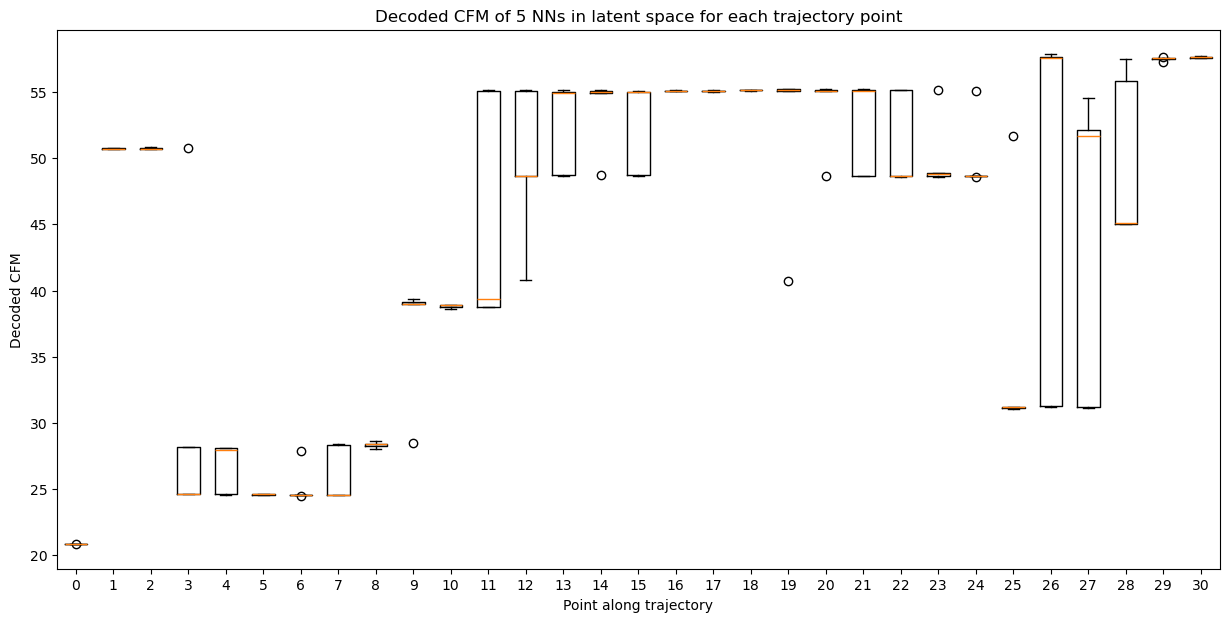

In [18]:
# Go along an example path (from one start, end pair) and plot decoded CFM of NNs
# Here k = 5 NNs

k = Config.KNN
nbrs = NearestNeighbors(n_neighbors=k).fit(latent_space)
z_point = path_example[0]
distances, indices = nbrs.kneighbors(z_point.reshape(1, -1))
print(distances)
print(indices)

cfm_csv_path=Config.CFM_CSV_PATH
df_cfm = pd.read_csv(cfm_csv_path)
mean_cfm = df_cfm['CFM_14_5_snRNA'].mean()
std_cfm  = df_cfm['CFM_14_5_snRNA'].std()

print(decoded_cfm_all[indices])
print(decoded_cfm_all[indices] * std_cfm + mean_cfm,'\n')

len(path_example)

cfm_neighbors = np.empty((31,k))
# positions = range(len(path_example))

plt.figure(figsize=(15,7))
plt.xlabel('Point along trajectory')
plt.ylabel('Decoded CFM')

for i in range(len(path_example)):
    z_point = path_example[i]
    distances, indices = nbrs.kneighbors(z_point.reshape(1, -1))
    new_neighbors = decoded_cfm_all[indices] * std_cfm + mean_cfm
    print(new_neighbors)
    cfm_neighbors[i] = new_neighbors[0]
    plt.boxplot(new_neighbors[0], positions=[i], widths=[0.6])
    plt.title('Decoded CFM of ' + str(k) + ' NNs in latent space for each trajectory point')

print(cfm_neighbors[26])

# plt.boxplot(cfm_neighbors[0])


# for z_point in path_example:
#     distances, indices = nbrs.kneighbors(z_point.reshape(1, -1))
#     print(decoded_cfm_all[indices]*std_cfm+mean_cfm)



[[0.         0.13503313 0.14665004 0.14767326 0.15548835 0.1555963
  0.15731648 0.15843784 0.18333375 0.19577456 0.19801746 0.19807358
  0.19833792 0.20216934 0.20362264 0.20450878 0.21142379 0.21199042
  0.21575769 0.21651069]]
[[55240 15569 54771 39036 28435 47123 49212 53038 23747 29825 31616 33918
  49681  4089  6254 36905 17556 46289 13583 45318]]
[[0.         0.13503313 0.14665004 0.14767326 0.15548835 0.1555963
  0.15731648 0.15843784 0.18333375 0.19577456 0.19801746 0.19807358
  0.19833792 0.20216934 0.20362264 0.20450878 0.21142379 0.21199042
  0.21575769 0.21651069]]
[[1.19100863 1.19461555 1.20113524 1.20350287 1.20767921 1.20813785
  1.20845518 1.20988828 1.21190179 1.21315052 1.21333844 1.21356078
  1.2163172  1.21724125 1.2195518  1.21959924 1.21967444 1.21977002
  1.22244689 1.22388144]]
[[1.20228545 1.23358233 1.24300772 1.25020392 1.29263842 1.31113819
  1.33045093 1.33933176 1.34344895 1.3508186  1.36205059 1.36432105
  1.3660805  1.36692445 1.37056952 1.38039794 1.38

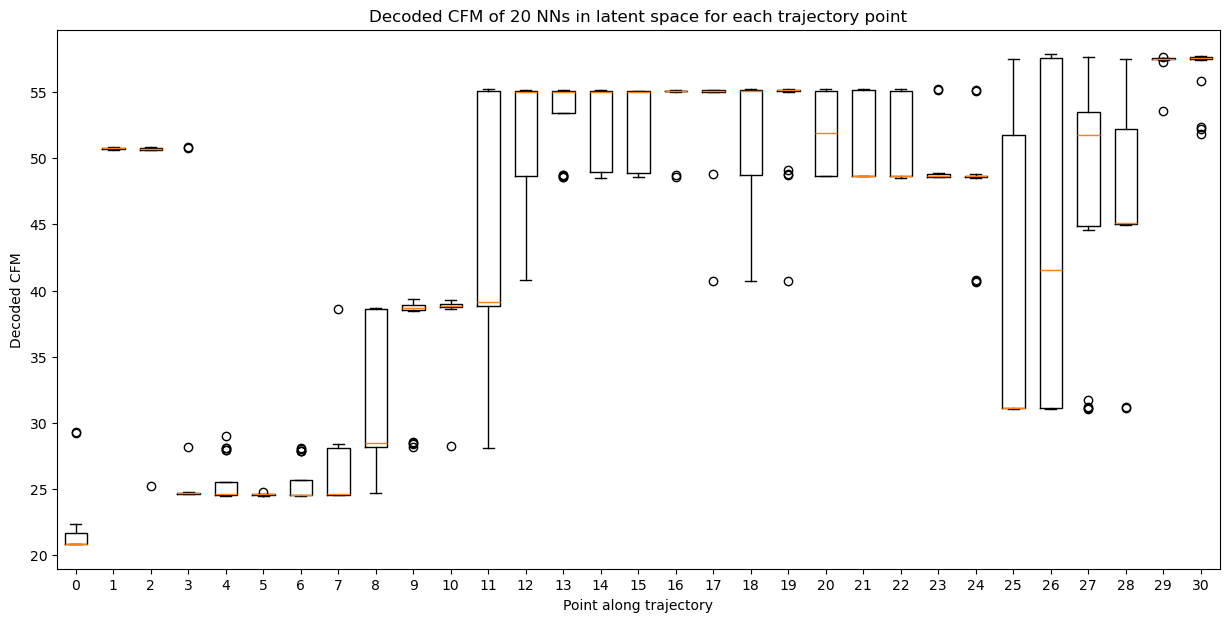

In [19]:
# Go along an example path and plot decoded CFM of k = 20 NNs

k = 20
nbrs = NearestNeighbors(n_neighbors=k).fit(latent_space)
z_point = path_example[0]
distances, indices = nbrs.kneighbors(z_point.reshape(1, -1))
print(distances)
print(indices)

# will use in loop below to count how many points within radius around each trajectory point
# not used in plot
radius = 4.038569

cfm_neighbors = np.empty((len(path_example),k))
density_counts = np.zeros((len(path_example)), dtype=int)
# positions = range(len(path_example))

plt.figure(figsize=(15,7))
plt.xlabel('Point along trajectory')
plt.ylabel('Decoded CFM')

for i in range(len(path_example)):
    z_point = path_example[i]
    distances, indices = nbrs.kneighbors(z_point.reshape(1, -1))
    print(distances)
    new_neighbors = decoded_cfm_all[indices] * std_cfm + mean_cfm
    # print(new_neighbors)
    cfm_neighbors[i] = new_neighbors[0]
    plt.boxplot(new_neighbors[0], positions=[i], widths=[0.6])
    plt.title('Decoded CFM of ' + str(k) + ' NNs in latent space for each trajectory point')

    # look at how many points in latent space within distance = radius of path point
    for j in range(len(latent_space)):
        dist_from_z = np.linalg.norm(latent_space[j,:] - z_point)
        if dist_from_z <= radius:
            density_counts[i] += 1




In [20]:
print(density_counts)
print(cfm_neighbors[29])

density_counts.T
df_density_counts = pd.DataFrame(density_counts)
print(df_density_counts)

[6120 6373 4245 1251  296  200   49    9   44  124   45    5   17   54
   85  101  136  291 1130 1919 1441  693  447  152   36  583 3222 5187
 6057 4940 3812]
[57.56824491 57.68368957 57.54135446 57.49820545 57.25298926 57.43309774
 57.51351194 57.50404028 57.57186031 57.4883848  57.55107409 57.50693015
 53.57566782 57.44695011 57.50523113 57.5458362  57.52603266 57.49617581
 57.51236396 57.58848622]
       0
0   6120
1   6373
2   4245
3   1251
4    296
5    200
6     49
7      9
8     44
9    124
10    45
11     5
12    17
13    54
14    85
15   101
16   136
17   291
18  1130
19  1919
20  1441
21   693
22   447
23   152
24    36
25   583
26  3222
27  5187
28  6057
29  4940
30  3812


(20, 31)
['point0', 'point1', 'point2', 'point3', 'point4', 'point5', 'point6', 'point7', 'point8', 'point9', 'point10', 'point11', 'point12', 'point13', 'point14', 'point15', 'point16', 'point17', 'point18', 'point19', 'point20', 'point21', 'point22', 'point23', 'point24', 'point25', 'point26', 'point27', 'point28', 'point29', 'point30']
       point0     point1     point2     point3     point4     point5  \
0   20.828423  50.740941  50.718187  50.758489  28.131041  24.605064   
1   20.834220  50.767189  50.847398  24.630274  28.134791  24.660926   
2   20.828423  50.663512  50.783362  24.624803  24.559804  24.576931   
3   20.828448  50.710775  50.705850  24.619496  27.968314  24.546901   
4   20.828423  50.684191  50.667948  28.160836  24.655900  24.627762   
5   20.874510  50.774138  50.701497  24.758903  24.670364  24.604683   
6   22.246190  50.683925  50.721352  24.698660  24.630880  24.607084   
7   20.828446  50.749734  50.779707  24.677347  24.660115  24.631345   
8   20.8284

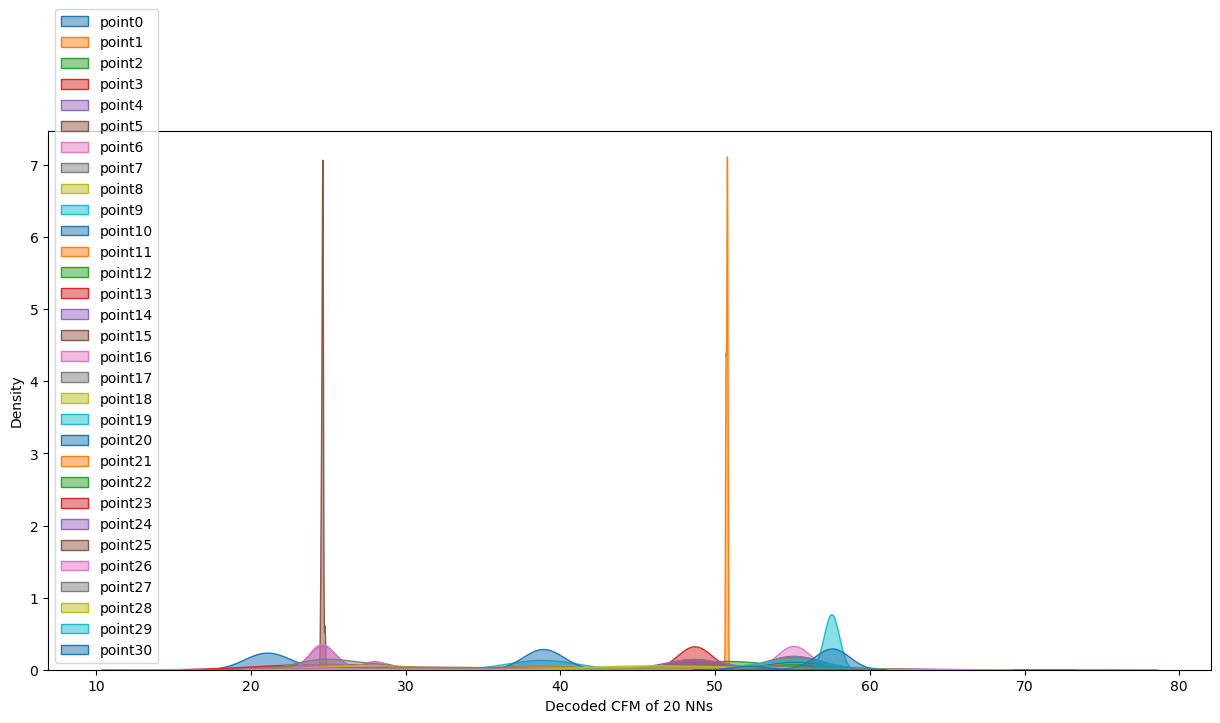

In [21]:
# KDE plot for all trajectory points on same axis

# cfm_neighbors: (num_steps, k)
# want to generate KDE plot, one subplot for each step in trajectory
# what is x-axis? step along trajectory or CFM?

# print(cfm_neighbors)

cfm_neighbors_transpose = cfm_neighbors.T

print(cfm_neighbors_transpose.shape)

column_names = []

for i in range(len(path_example)):
    column_names.append('point' + str(i))

print(column_names)
df_cfm_neighbors = pd.DataFrame(cfm_neighbors_transpose, columns=column_names)
print(df_cfm_neighbors)

plt.figure(figsize=(15,7))
# plt.xlim(17,63)
# plt.ylim(0,0.3)
plt.xlabel('Decoded CFM of 20 NNs')

colors_husl = sns.color_palette("husl", 31)

for i in range(len(path_example)):
    x_name = 'point'+str(i)
    sns.kdeplot(data=df_cfm_neighbors, x=x_name, alpha=0.5, common_norm=False, fill=True, bw_adjust=1, label = x_name)

sns.color_palette("husl", 8)
plt.legend()

# create a data frame for easier plotting

# df_cfm_neighbors['id'] = df_cfm_neighbors.index
# df_reshaped_cfm_neighbors = pd.wide_to_long(df_cfm_neighbors, stubnames='point', i='id', j='point')

# try making dictionary with lists for column entries, then make a data frame from that dictionary

cfm_data = {
    'cfm': [],
    'traj_point': []
}

print(cfm_data)

# for i in range(len(path_example)):
#     # i goes from 0 to 30
#     # for each i, fill in 20 rows of traj_point with "point{i}"
#     for j in range(k):
#         # j goes from 0 to 19
#         cfm_data['cfm'][]


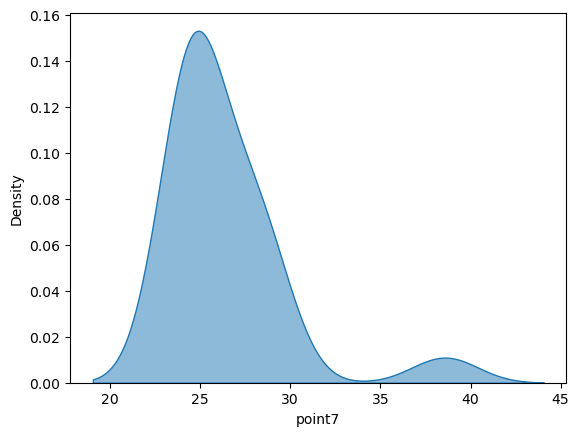

In [22]:
# sample plot for individual trajectory points

ax = sns.kdeplot(data=df_cfm_neighbors, x='point7', alpha=0.5, common_norm=False, fill=True, bw_adjust=1)

In [23]:
# I don't like this

# df_cfm_neighbors["id"] = df_cfm_neighbors.index
# # df_cfm_neighbors["id"] = df_cfm_neighbors["id"].astype(str)
# df_cfm_neighbors

# df_cfm_neighbors_reshaped = pd.wide_to_long(df_cfm_neighbors, stubnames="point", i="id",j="traj_point")

# print(df_cfm_neighbors_reshaped)

cfm_neighbors_reshape = cfm_neighbors.reshape(k*len(path_example),)
print(cfm_neighbors_reshape.shape)

point_ids = np.zeros((k*len(path_example),), dtype='U10') # U10 instead of str because by default dtype=str only takes one character/U1
print(point_ids.shape)

local_density = np.zeros((k*len(path_example),), dtype=int)
print(local_density.shape)
print(density_counts)

for i in range(len(path_example)):
    point_name = 'point' + str(i)
    for j in range(k):
        point_ids[i*k + j] = point_name
        local_density[i*k + j] = density_counts[i]

cfm_data = {
    'cfm': cfm_neighbors_reshape,
    'traj_point': point_ids,
    'local_density': local_density
}

df_cfm_neighbors_reshaped = pd.DataFrame(cfm_data, columns=['cfm', 'traj_point', 'local_density'])
print(df_cfm_neighbors_reshaped.loc[:41,:])


(620,)
(620,)
(620,)
[6120 6373 4245 1251  296  200   49    9   44  124   45    5   17   54
   85  101  136  291 1130 1919 1441  693  447  152   36  583 3222 5187
 6057 4940 3812]
          cfm traj_point  local_density
0   20.828423     point0           6120
1   20.834220     point0           6120
2   20.828423     point0           6120
3   20.828448     point0           6120
4   20.828423     point0           6120
5   20.874510     point0           6120
6   22.246190     point0           6120
7   20.828446     point0           6120
8   20.828484     point0           6120
9   20.828423     point0           6120
10  22.370288     point0           6120
11  22.332213     point0           6120
12  29.256476     point0           6120
13  20.828423     point0           6120
14  20.828455     point0           6120
15  20.828737     point0           6120
16  20.828431     point0           6120
17  20.828439     point0           6120
18  29.329579     point0           6120
19  21.499357     po

<Axes: xlabel='cfm', ylabel='Density'>

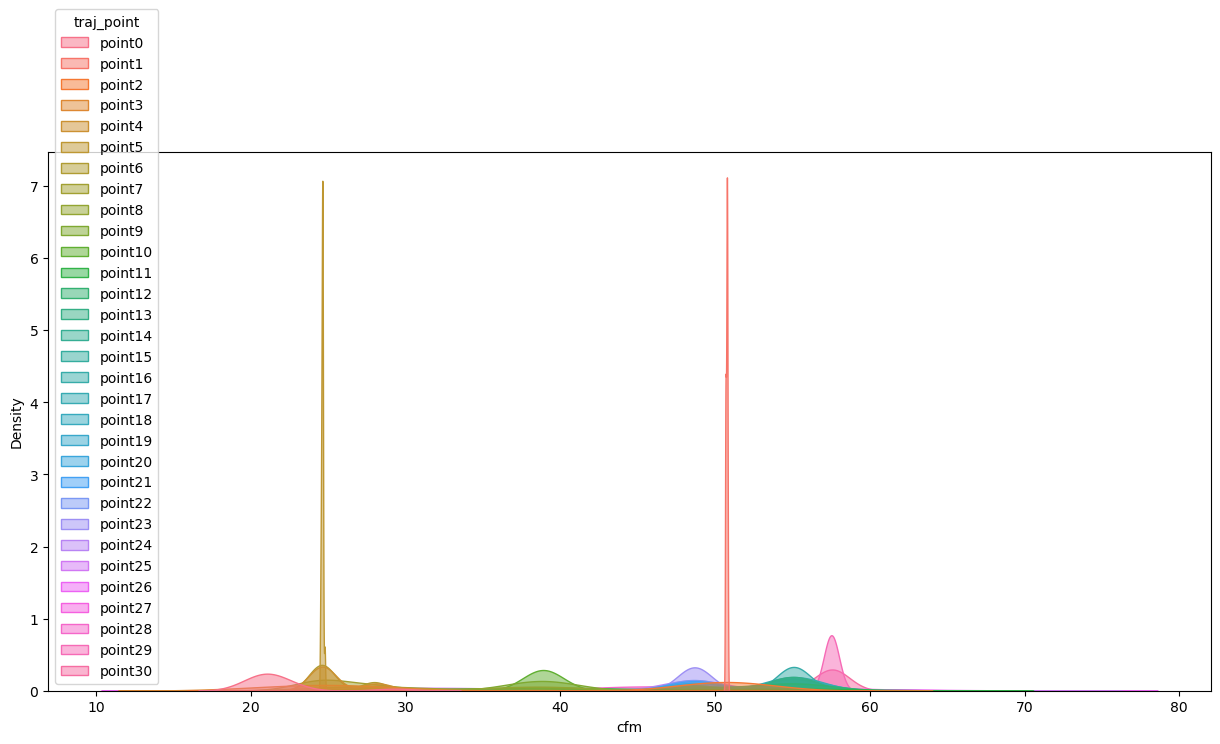

In [24]:
# KDE plot with nicer colors?
# can adjust axes to zoom in and see distributions better (commented out below)

plt.figure(figsize=(15,7))
# plt.xlim(17,63)
# plt.ylim(0,0.3)
sns.kdeplot(data=df_cfm_neighbors_reshaped, x='cfm', hue='traj_point', alpha=0.5, common_norm=False, fill=True, bw_adjust=1)

15.73650024703268
34.421501485860695
50.54712667331176
50.913406728379826
13.611596882669804
62.48904935640792
8.759903233401655
66.68600456754423
21.33194814981634
32.18921147895698
24.358792508601436
24.879257421716574
21.537095433461275
31.02550252128627
17.797420302253254
45.31166275576177
13.34913446907959
50.04851890132233
19.84137918513928
47.63551206829665
23.41120630316684
44.14759001167016
9.883867595732674
73.46108616644345
31.482936160299207
64.45179137913587
43.07562728362939
60.626671067549005
42.73064302988229
60.86742114317443
42.793293849250425
60.870147430563215
44.623941175794016
59.071607010540816
33.77747069802598
62.138455872072726
32.569205441554196
63.36707570724965
33.16362928551752
62.79760451346311
42.30864815870959
61.54845091158181
42.36046127247242
61.533921361369856
42.44618711908882
61.30892476672951
44.589841086549924
59.22125277863082
33.15794556892418
62.660042384957976
9.016205321044463
79.51233778296567
6.887040613732825
82.02566416768175
12.6656723

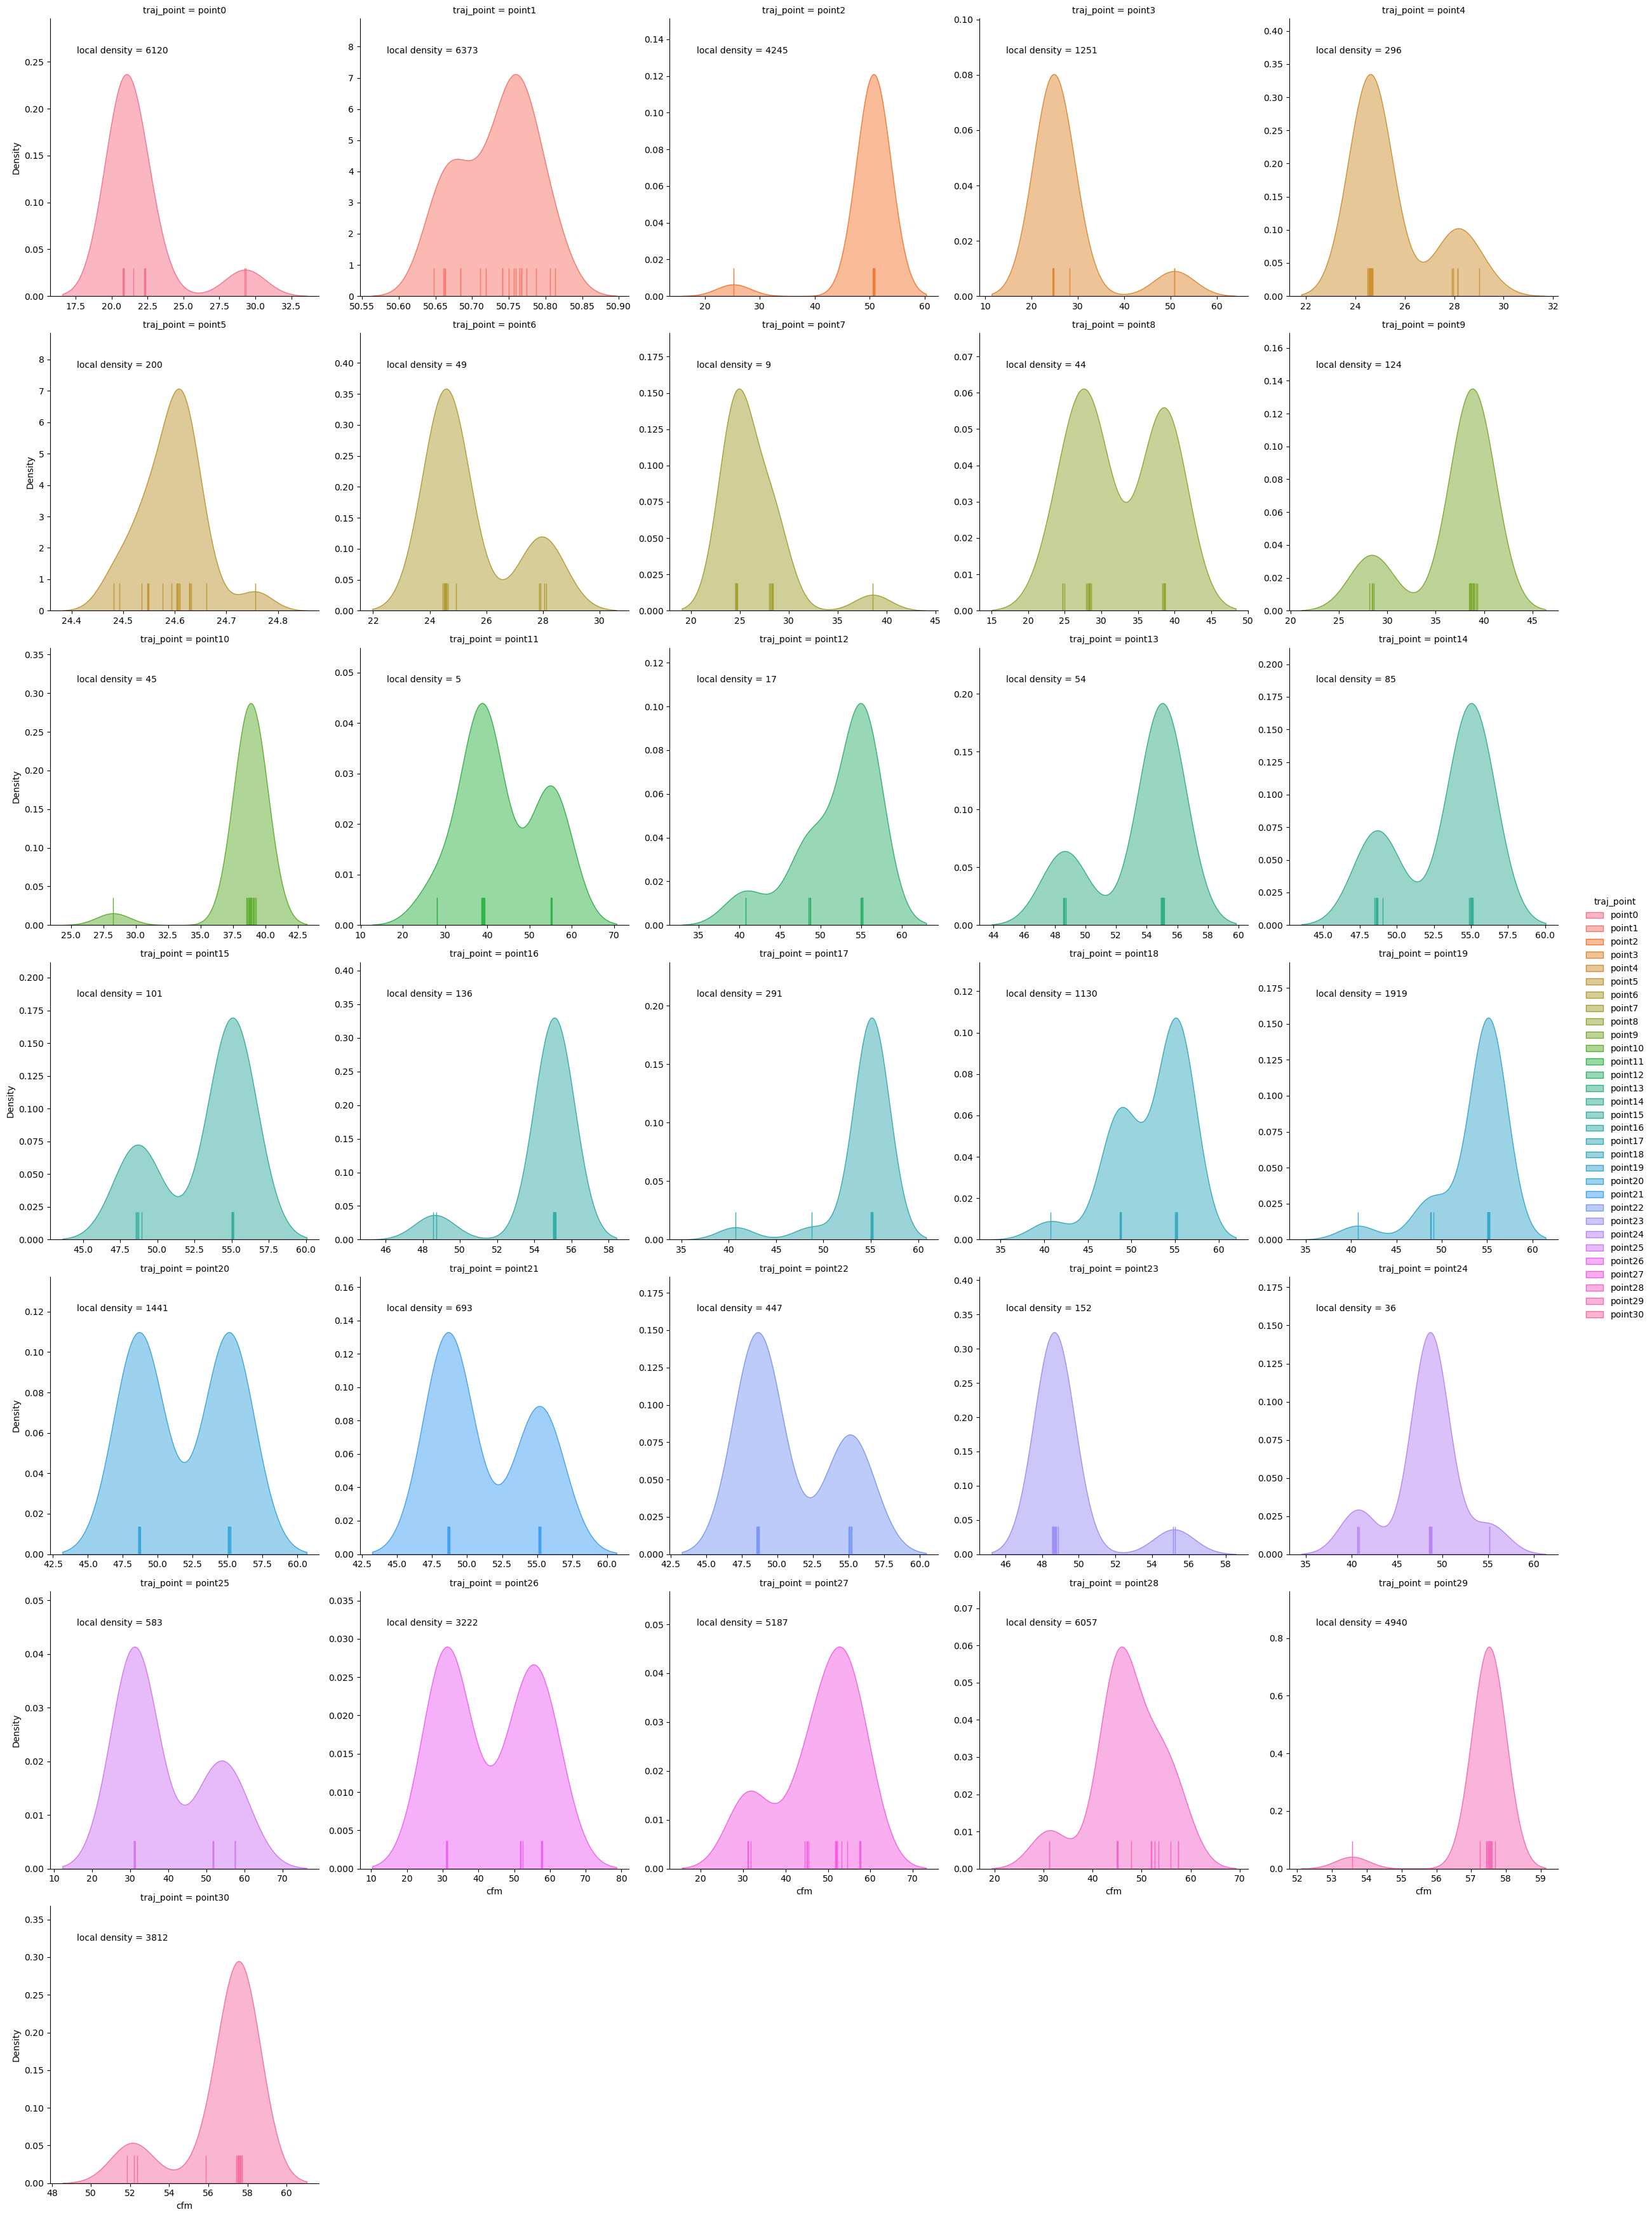

In [25]:
# KDE plots for each trajectory point (should change x-axes to be the same for better comparison)

# sns.displot(data=df_cfm_neighbors_reshaped, x='cfm', hue='traj_point', col='traj_point', alpha=0.5, common_norm=False, fill=True, bw_adjust=1)
# change kind='kde' to kde=True in order to get histogram + kde overlaid
# kwargs={'alpha':0.5, 'common_norm':False, 'fill':True, 'bw_adjust':1}
g = sns.displot(data=df_cfm_neighbors_reshaped, x='cfm', hue='traj_point', col='traj_point', col_wrap=5, fill=True, kind='kde', alpha=0.5, common_norm=False, bw_adjust=1, rug=True, rug_kws={'height':0.1}, facet_kws={'sharex': False, 'sharey': False})

for i in range(len(path_example)):
    ax = g.axes.flat[i]
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    density_value = density_counts[i]
    print(xmin)
    print(xmax)
    ax.text(x=xmin+(xmax-xmin)/10, y=ymax-(ymax-ymin)/10, s='local density = ' + str(density_value), horizontalalignment='left', verticalalignment='top', fontsize=10, color='black')

In [26]:
df_latent

,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9,z_10,label,decoded_cfm
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,2,1.048495
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,3,1.236806
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,2,1.044764
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,3,-0.825561
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,0,0.690024
...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,3,0.267969
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,0,-0.972245
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,2,0.547159
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,3,1.229240


In [27]:
print(decoded_cfm_all)
print(decoded_cfm_all.shape)

nbrs = NearestNeighbors(n_neighbors=k).fit(latent_space)
_, indices = nbrs.kneighbors(z_point.reshape(1, -1))

# z, latent_space, labels, k

# check that I'm grabbing the correct value - helpful for pp trajectory method
print(decoded_cfm_all[18260])
print(df_latent.loc[18260,'decoded_cfm'])

[1.0484947  1.23680604 1.0447644  ... 0.5471586  1.22924006 0.54221261]
(56650,)
-1.623062014579773
-1.623062014579773


## Generating trajectory along straight line using new method

Define desired local density (# points in neighborhood of trajectory point)

Choose radius to yield that density

Take step of size 2*radius (get proposed point)

Find existing data point closest to proposed point
- previously, was interpolating along straight line--i.e., generating new point--but didn't have a method of decoding CFM because needed bin
- could use old method of determining bin OR use something like what I'm doing/will end up doing for generated CFM

In [90]:
# making trajectory using new method
start_index = 18260
end_index = 46470
k = 100

# print(df_latent.loc[start_index,:])
# print(df_latent.loc[end_index,:])

start_coordinate = latent_space[start_index,:]
end_coordinate = latent_space[end_index,:]

path_new = []
path_indices = []

# make unit vector orthogonal to target axis to reference angles later
random_vector = np.random.rand(latent_dim)
reference_vector, reference_vector_dist = perpendicular_projection(start_coordinate, end_coordinate, random_vector)
if reference_vector_dist > 0:
    reference_vector /= reference_vector_dist

# MAKE DICTIONARY LIKE I DID FOR PP TRAJECTORY --> WANT TO PLOT CFM, BIN DIST

traj_info = []

print(latent_space.shape)
print(start_coordinate)

path_new.append(start_coordinate)
path_indices.append(start_index)

# first just do a trajectory in direction toward goal to see density, step size

# direction toward goal
target_dir = end_coordinate - start_coordinate
target_norm = np.linalg.norm(target_dir)
print(target_norm, '\n')
if target_norm > 0:
    target_dir /= target_norm

cur_point = start_coordinate
cur_index = start_index

cur_dist_to_goal = np.linalg.norm(end_coordinate - cur_point)
proposed_next_step_size = 0
num_steps = 0

nbrs = NearestNeighbors(n_neighbors=k).fit(latent_space)
distances, indices = nbrs.kneighbors(cur_point.reshape(1, -1))
# print(distances[0][-1])
# print(distances[0][0])
# print(indices)

print('local density = ', k)

closest_point_to_proposed_point_distances = []
closest_point_to_line_distances = []
closest_point_to_line_vectors = []
closest_point_angles = []

# check order of everything here to make sure comparing correctly
while proposed_next_step_size < cur_dist_to_goal:
    # direction to goal - ADDED THIS RECENTLY, CHECK
    target_dir = end_coordinate - cur_point
    target_norm = np.linalg.norm(target_dir)
    print(target_norm, '\n')
    if target_norm > 0:
        target_dir /= target_norm
    
    cur_dist_to_goal = np.linalg.norm(end_coordinate - cur_point)
    print ('current distance to goal = ', cur_dist_to_goal)
    # find k nearest neighbors?
    # find distance to farthest?
    distances, indices = nbrs.kneighbors(cur_point.reshape(1, -1))
    radius = distances[0][-1] # distance to farthest neighbor
    proposed_next_step_size = 2*radius

    # add information about CURRENT point to dictionary
    # want to fix this so it does this later? not sure

    cfm_neighbor_all = []
    bin_neighbor_all = []

    cur_point_cfm = decoded_cfm_all[cur_index]
    cur_point_bin = df_latent.loc[cur_index, 'label']

    for i in range(distances.shape[1]):
        # print(i)
        neighbor_index = indices[0][i]
        # print('neighbor index = ', neighbor_index)
        cfm_neighbor = decoded_cfm_all[neighbor_index]
        # print('cfm of this neighbor = ', cfm_neighbor)
        bin_neighbor = df_latent.loc[neighbor_index, 'label']

        cfm_neighbor_all.append(float(cfm_neighbor))
        bin_neighbor_all.append(int(bin_neighbor))

    new_dict = {
        'index': int(cur_index),
        'coordinate': cur_point,
        'local density': int(distances.shape[1]),
        'radius': float(radius),
        'decoded CFM': float(cur_point_cfm),
        'bin': int(cur_point_bin),
        'neighbor CFM': cfm_neighbor_all,
        'neighbor bins': bin_neighbor_all
    }

    traj_info.append((new_dict))

    # FIX THIS - HOW DO I GET IT TO CHECK???
    if proposed_next_step_size > cur_dist_to_goal:
        break

    # used to have new stuff here for dict

    next_step_size = proposed_next_step_size
    print('step size = ', next_step_size)

    proposed_next_point = cur_point + target_dir*next_step_size

    # find existing point closest to proposed point
    proposed_point_dist, proposed_point_idx = nbrs.kneighbors(proposed_next_point.reshape(1, -1))
    closest_point_dist = proposed_point_dist[0][0]
    closest_point_idx = proposed_point_idx[0][0]

    print('index of closest point = ', closest_point_idx)
    print('distance to closest point = ', closest_point_dist)

    # dist_from_first_point = np.linalg.norm(latent_space[0,:] - proposed_next_point)
    # shortest_dist = dist_from_first_point

    # for i in range(len(latent_space)):
    #     dist_to_proposed_point = np.linalg.norm(latent_space[i,:] - proposed_next_point)
    #     if dist_to_proposed_point < shortest_dist:
    #         shortest_dist = dist_to_proposed_point
    
    # print('distance to closest point using other method = ', shortest_dist)

    # print(closest_point_dist == shortest_dist)

    next_point = latent_space[closest_point_idx,:]

    closest_point_vector_from_axis, closest_point_dist_from_axis = perpendicular_projection(start_coordinate, end_coordinate, next_point)
    angle_vector_with_ref = math.acos(np.dot(closest_point_vector_from_axis, reference_vector) / closest_point_dist_from_axis)
    angle_vector_with_ref = math.degrees(angle_vector_with_ref)

    # arccos only gives angles in upper half of plane, put in correct quadrant
    # check sin of angle --> if negative, convert angle to correct quadrant
    if math.sin(angle_vector_with_ref) < 0:
        angle_vector_with_ref = 360 - angle_vector_with_ref
    
    print('distance from closest point to axis = ', closest_point_dist_from_axis)
    print('vector from axis to closest point = ', closest_point_vector_from_axis)
    print('angle of closest point = ', angle_vector_with_ref)

    closest_point_to_proposed_point_distances.append(closest_point_dist)
    closest_point_to_line_distances.append(closest_point_dist_from_axis)
    closest_point_to_line_vectors.append(closest_point_vector_from_axis)
    closest_point_angles.append(angle_vector_with_ref)

    # check that perpendicular vector and target axis are orthogonal
    print(np.dot(end_coordinate-start_coordinate, closest_point_vector_from_axis))

    # decoded_cfm_all[indices] * std_cfm + mean_cfm

    path_new.append(next_point)
    path_indices.append(closest_point_idx)
    num_steps += 1

    cur_point = next_point
    cur_index = closest_point_idx

# final_step_size = cur_dist_to_goal
# print('final step size = ', final_step_size)

path_new.append(end_coordinate)
path_indices.append(end_index)

last_dict = {
    'index': int(end_index),
    'coordinate': end_coordinate,
    'local density': int(0),
    'radius': float(0),
    'decoded CFM': float(decoded_cfm_all[end_index]),
    'bin': int(df_latent.loc[end_index,'label']),
    'neighbor CFM': cfm_neighbor_all,
    'neighbor bins': bin_neighbor_all
}

traj_info.append((last_dict))

print('number of interpolated points = ', num_steps)


# k = 2000
# nbrs = NearestNeighbors(n_neighbors=k).fit(latent_space)
# z_point = path_example[0]
# distances, indices = nbrs.kneighbors(z_point.reshape(1, -1))
# print(distances)
# print(indices)

# radius = 4.038569

# cfm_neighbors = np.empty((len(path_example),k))
# density_counts = np.zeros((len(path_example)), dtype=int)
# # positions = range(len(path_example))

# plt.figure(figsize=(15,7))
# plt.xlabel('Point along trajectory')
# plt.ylabel('Decoded CFM values of 20 nearest neighbors in latent space')

# for i in range(len(path_example)):
#     z_point = path_example[i]
#     distances, indices = nbrs.kneighbors(z_point.reshape(1, -1))
#     print(distances)
#     new_neighbors = decoded_cfm_all[indices] * std_cfm + mean_cfm
#     # print(new_neighbors)
#     cfm_neighbors[i] = new_neighbors[0]
#     plt.boxplot(new_neighbors[0], positions=[i], widths=[0.6])

#     # look at how many points in latent space within distance = radius of path point
#     for j in range(len(latent_space)):
#         dist_from_z = np.linalg.norm(latent_space[j,:] - z_point)
#         if dist_from_z <= radius:
#             density_counts[i] += 1

(56650, 10)
[-8.407204  -4.2466807  2.881962   9.409945  14.161424  19.746548
 26.679409  30.815266  39.04207   44.011818 ]
117.1185 

local density =  100
117.1185 

current distance to goal =  117.1185
step size =  0.6189949808714071
index of closest point =  47123
distance to closest point =  0.1025110311345665
distance from closest point to axis =  0.0897012
vector from axis to closest point =  [-0.03900242 -0.04127264  0.02297354 -0.01144028 -0.02361393  0.03986931
 -0.01075172  0.00686455  0.04021072 -0.01536942]
angle of closest point =  240.70378732344471
-0.00019398332
116.44992 

current distance to goal =  116.44992
step size =  0.5915854346108091
index of closest point =  54855
distance to closest point =  0.12781889407591845
distance from closest point to axis =  0.15574357
vector from axis to closest point =  [-0.10349655 -0.04637909  0.00724411 -0.05308247  0.06444931  0.03201103
 -0.01505661 -0.01807213  0.0504837   0.01558685]
angle of closest point =  230.983834110187

In [91]:
traj_filename = 'traj_info_10D_line_existing_points_' + str(k) + 'NNs.pkl'
print(traj_filename)
traj_filepath = '/home/nghayes/latent-space-trajectories/' + traj_filename
print(traj_filepath)

with open (traj_filepath, 'wb') as file:
    pickle.dump(traj_info, file)

traj_info_10D_line_existing_points_100NNs.pkl
/home/nghayes/latent-space-trajectories/traj_info_10D_line_existing_points_100NNs.pkl


In [92]:
# counting how many points in each "quadrant" by looking at angles around target axis

quad1_count = 0
quad2_count = 0
quad3_count = 0
quad4_count = 0

for angle in closest_point_angles:
    if angle < 90:
        quad1_count += 1
    elif angle >= 90 and angle < 180:
        quad2_count += 1
    elif angle >= 180 and angle < 270:
        quad3_count += 1
    elif angle >= 270 and angle < 360:
        quad4_count += 1

print(quad1_count)
print(quad2_count)
print(quad3_count)
print(quad4_count)


16
14
12
19


In [93]:
# inspecting outputs of trajectory generation

# closest_point_to_proposed_point_distances
# closest_point_to_line_distances
# closest_point_to_line_vectors
closest_point_angles

[240.70378732344471,
 230.9838341101872,
 133.92959624070306,
 120.29308533951809,
 97.23760381589112,
 305.5885625209856,
 310.0652964835924,
 46.4294727561251,
 266.6498455145458,
 94.83260221165534,
 209.83773958197688,
 146.91430997593312,
 147.63056595384214,
 235.43223338802522,
 242.12234532752348,
 108.4307236702633,
 108.2480601617438,
 109.42818716011304,
 108.56195765770455,
 109.63609571094095,
 249.33334234997088,
 249.12469869697978,
 248.34894148131548,
 247.60054419319133,
 114.87653798381606,
 121.05784058288594,
 122.19215310545782,
 230.18732873030532,
 236.22738773894002,
 89.10535295514467,
 82.68616636656006,
 77.26969555809787,
 278.6868939710889,
 83.32326233952078,
 278.7126947977502,
 274.9771628283,
 59.3178145869247,
 323.4791106905747,
 343.2400489781795,
 342.81515543621464,
 341.8414007925639,
 20.320248084528796,
 21.670318394197235,
 20.83487536873467,
 20.449727048974058,
 343.92341716913677,
 342.8885059723628,
 342.5742084216864,
 20.00856739168986,


### Analysis of new trajectories

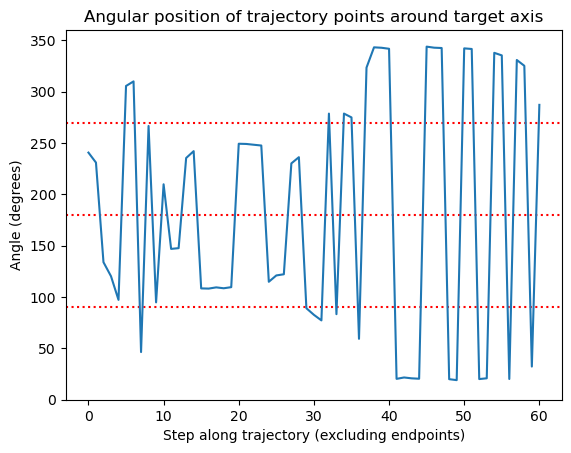

In [94]:
plt.figure()
plt.ylim((0,360))
for val in [90, 180, 270]:
    plt.axhline(y=val, color='r', linestyle=':')
plt.plot(closest_point_angles)
plt.title('Angular position of trajectory points around target axis')
plt.xlabel('Step along trajectory (excluding endpoints)')
plt.ylabel('Angle (degrees)')
plt.show()

<Figure size 2000x700 with 0 Axes>

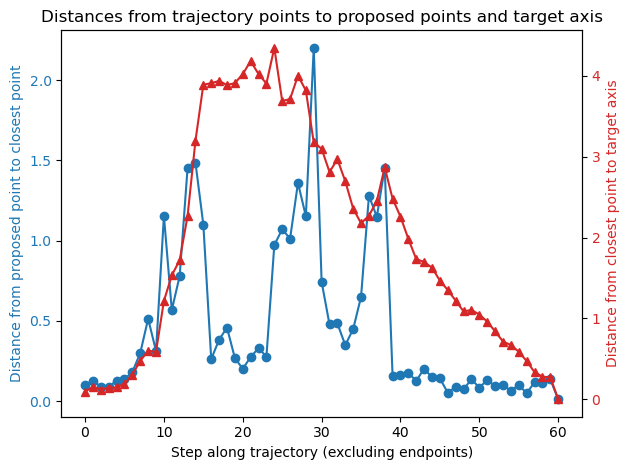

117.1185


In [95]:
# closest_point_to_proposed_point_distances
# closest_point_to_line_distances

figsize=(20, 7)
plt.figure(figsize=figsize)

fig, ax1 = plt.subplots()

ax1.set_xlabel('Step along trajectory (excluding endpoints)')
ax1.set_ylabel('Distance from proposed point to closest point', color='tab:blue')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel('Distance from closest point to target axis', color='tab:red')  # we already handled the x-label with ax1

plt.title('Distances from trajectory points to proposed points and target axis')

ax1.plot(closest_point_to_proposed_point_distances,'-o',color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.plot(closest_point_to_line_distances,'-^',color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

# print length of target axis to compare computed distances
print(np.linalg.norm(end_coordinate-start_coordinate))

In [96]:
traj_info[2]

{'index': 54855,
 'coordinate': array([-8.7677   , -4.546082 ,  2.5809782,  9.003708 , 13.86635  ,
        19.397148 , 26.229553 , 30.369263 , 38.584446 , 43.507988 ],
       dtype=float32),
 'local density': 100,
 'radius': 0.2741181711645898,
 'decoded CFM': -1.6220911741256714,
 'bin': 0,
 'neighbor CFM': [-1.6220911741256714,
  -1.5763442516326904,
  -1.50662100315094,
  -1.6177340745925903,
  -1.5897785425186155,
  -1.5125066041946411,
  -1.58896803855896,
  -1.6229673624038696,
  -1.623055338859558,
  -1.623062014579773,
  -1.568516492843628,
  -1.60699462890625,
  -1.6230618953704834,
  -1.5875697135925293,
  -1.42782723903656,
  -1.274538516998291,
  -1.6230604648590088,
  -1.6182204484939575,
  -1.6221795082092283,
  -1.6230616569519043,
  -1.6174037456512451,
  -1.502278447151184,
  -1.6230403184890747,
  -1.6228407621383667,
  -1.5142279863357544,
  -1.620121955871582,
  -1.5952421426773071,
  -1.623062014579773,
  -1.61788809299469,
  -1.5818026065826416,
  -1.6218812465667

In [97]:
traj_point = latent_space[15941,:]
radius = 0.2

test_neighbors = []
test_neighbor_indices = []

for i in range(len(latent_space)):
    if np.linalg.norm(traj_point - latent_space[i,:]) < radius:
        test_neighbors.append(latent_space[i,:])
        test_neighbor_indices.append(i)

print(len(test_neighbors))

test_cfm_neighbors = []

for index in test_neighbor_indices:
    cfm = df_latent.loc[index,'decoded_cfm']* std_cfm + mean_cfm
    test_cfm_neighbors.append(cfm)

print(test_cfm_neighbors)


24
[np.float64(21.26081795548915), np.float64(21.115822577869984), np.float64(20.834591730432034), np.float64(20.89241355064297), np.float64(20.828449233489362), np.float64(21.085301424359656), np.float64(22.958014504209174), np.float64(20.82843239634349), np.float64(22.291306386014607), np.float64(21.695517856866882), np.float64(29.166876587973526), np.float64(29.182414977635517), np.float64(29.153970150340676), np.float64(29.109102217900947), np.float64(29.203723916381456), np.float64(20.919680543051847), np.float64(23.31727327754962), np.float64(21.906680156449152), np.float64(20.829970699216005), np.float64(21.413912000270958), np.float64(20.828498214277342), np.float64(21.43602223409526), np.float64(24.12670988126963), np.float64(29.089804552761457)]


Text(0.5, 1.0, 'CFM distribution for point 2 with r = 0.2, 24 neighbors')

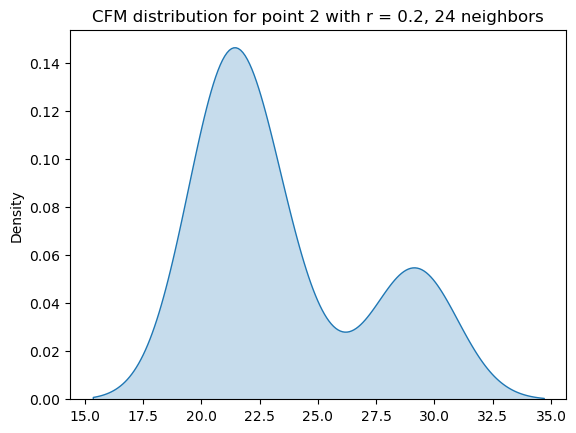

In [98]:
sns.kdeplot(test_cfm_neighbors, fill=True)
plt.title('CFM distribution for point 2 with r = 0.2, 24 neighbors')

In [99]:
len(path_indices)

63

[20.828423212445745, 20.874509541986487, 20.840888822986773, 20.828424743095372, 22.37874933775673, 20.950792527317187, 20.925382212902697, 21.28592673192763, 50.78298533520901, 50.81187787751899, 50.84739813270257, 24.758903381083837, 24.686460795660732, 24.46805546205585, 24.62776191321502, 28.056654322539185, 28.265462482999148, 24.603412338990232, 38.258106510075294, 24.64174439753382, 27.877240757465998, 27.762440504987165, 27.88766754270734, 27.8641368660316, 28.1637156105171, 48.856512779251695, 48.5451296648629, 48.60127083178625, 55.06544909952283, 55.102968383115865, 55.056353979454705, 55.03338811249037, 55.06566951306874, 48.77566386609144, 48.67802678785088, 48.65276800774921, 48.69222203246748, 48.567069996578894, 48.606573002085135, 31.068332206469826, 31.061135857260762, 31.035424004870265, 31.089664870284942, 31.075123698853247, 31.054885449519567, 31.03882816963491, 44.983187067588304, 45.58312977981662, 45.09223207747943, 44.954142990965515, 45.025215644974786, 45.07

<Figure size 2000x700 with 0 Axes>

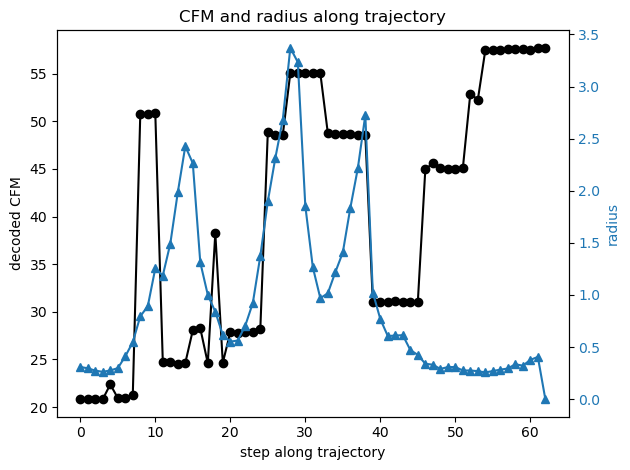

In [100]:
# df_cfm_neighbors_reshaped = pd.DataFrame(traj_info[0], columns=['original_index', 'local_density', 'radius'])

figsize=(20, 7)
plt.figure(figsize=figsize)

fig, ax1 = plt.subplots()

ax1.set_xlabel('step along trajectory')
ax1.set_ylabel('decoded CFM', color='black')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel('radius', color='tab:blue')  # we already handled the x-label with ax1

plt.title('CFM and radius along trajectory')

all_cfm = []
all_pp = []

for i in range(len(traj_info)):
    descaled_cfm = traj_info[i]['decoded CFM'] * std_cfm + mean_cfm
    all_cfm.append(float(descaled_cfm))
    # print(traj_info[i])
    
    pp_value = traj_info[i]['radius']
    all_pp.append(pp_value)

print(all_cfm)
print(all_pp)

ax1.plot(all_cfm, '-o',color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax2.plot(all_pp, '-^',color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

In [101]:
df_list=[]

for traj_index in range(len(traj_info)-1):

    df_traj_new = pd.DataFrame({
        'traj_point': pd.Series(dtype='str'),
        'index': pd.Series(dtype='int'),
        'local_density': pd.Series(dtype='int'),
        'radius': pd.Series(dtype='float'),
        'decoded_cfm': pd.Series(dtype='float'),
        'bin': pd.Series(dtype='int'),
        'neighbor_cfm': pd.Series(dtype='float'),
        'neighbor_bins': pd.Series(dtype='int')
    })

    df_traj_new['neighbor_cfm'] = traj_info[traj_index]['neighbor CFM']
    df_traj_new['neighbor_bins'] = traj_info[traj_index]['neighbor bins']
    df_traj_new['decoded_cfm'] = traj_info[traj_index]['decoded CFM']
    df_traj_new['bin'] = traj_info[traj_index]['bin']
    df_traj_new['radius'] = traj_info[traj_index]['radius']
    df_traj_new['local_density'] = traj_info[traj_index]['local density']
    df_traj_new['index'] = traj_info[traj_index]['index']
    df_traj_new['traj_point'] = 'point_' + str(traj_index)

    print(df_traj_new)

    df_list.append(df_traj_new)

   traj_point  index  local_density    radius  decoded_cfm  bin  neighbor_cfm  \
0     point_0  18260            100  0.309497    -1.623062    0     -1.623062   
1     point_0  18260            100  0.309497    -1.623062    0     -1.623062   
2     point_0  18260            100  0.309497    -1.623062    0     -1.623062   
3     point_0  18260            100  0.309497    -1.623062    0     -1.623062   
4     point_0  18260            100  0.309497    -1.623062    0     -1.623016   
..        ...    ...            ...       ...          ...  ...           ...   
95    point_0  18260            100  0.309497    -1.623062    0     -1.623062   
96    point_0  18260            100  0.309497    -1.623062    0     -1.622789   
97    point_0  18260            100  0.309497    -1.623062    0     -1.622969   
98    point_0  18260            100  0.309497    -1.623062    0     -1.616038   
99    point_0  18260            100  0.309497    -1.623062    0     -0.979246   

    neighbor_bins  
0      

In [102]:
df_traj_all = pd.concat(df_list, ignore_index=True)
df_traj_all

,traj_point,index,local_density,radius,decoded_cfm,bin,neighbor_cfm,neighbor_bins
0,point_0,18260,100,0.309497,-1.623062,0,-1.623062,0
1,point_0,18260,100,0.309497,-1.623062,0,-1.623062,0
2,point_0,18260,100,0.309497,-1.623062,0,-1.623062,0
3,point_0,18260,100,0.309497,-1.623062,0,-1.623062,0
4,point_0,18260,100,0.309497,-1.623062,0,-1.623016,0
...,...,...,...,...,...,...,...,...
6195,point_61,46470,100,0.405563,1.249484,3,0.817851,3
6196,point_61,46470,100,0.405563,1.249484,3,0.790607,3
6197,point_61,46470,100,0.405563,1.249484,3,-0.829738,3
6198,point_61,46470,100,0.405563,1.249484,3,1.246729,3


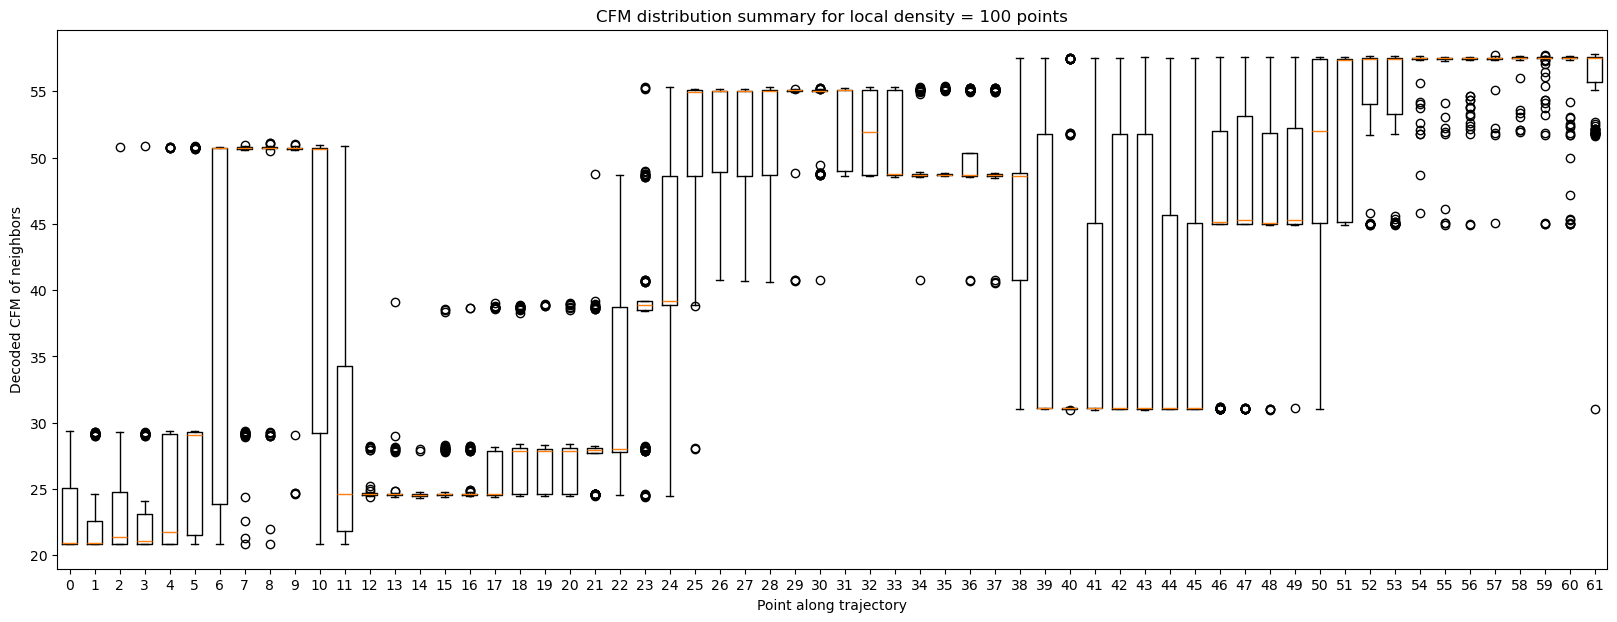

In [103]:
plt.figure(figsize=(20,7))
plt.xlabel('Point along trajectory')
plt.ylabel('Decoded CFM of neighbors')
plt.title('CFM distribution summary for local density = ' + str(k) + ' points')

for i in range(len(traj_info)-1):
    df_traj = df_list[i]
    neighbors_cfm = df_traj['neighbor_cfm'] * std_cfm + mean_cfm
    # print(new_neighbors)
    plt.boxplot(neighbors_cfm, positions=[i], widths=[0.6])

In [104]:
df_traj_all['neighbor_cfm'] = df_traj_all['neighbor_cfm'] * std_cfm + mean_cfm
df_traj_all

,traj_point,index,local_density,radius,decoded_cfm,bin,neighbor_cfm,neighbor_bins
0,point_0,18260,100,0.309497,-1.623062,0,20.828423,0
1,point_0,18260,100,0.309497,-1.623062,0,20.828425,0
2,point_0,18260,100,0.309497,-1.623062,0,20.828423,0
3,point_0,18260,100,0.309497,-1.623062,0,20.828426,0
4,point_0,18260,100,0.309497,-1.623062,0,20.829008,0
...,...,...,...,...,...,...,...,...
6195,point_61,46470,100,0.405563,1.249484,3,52.169797,3
6196,point_61,46470,100,0.405563,1.249484,3,51.819976,3
6197,point_61,46470,100,0.405563,1.249484,3,31.014714,3
6198,point_61,46470,100,0.405563,1.249484,3,57.676600,3


In [105]:
indices_for_trajectory = df_traj_all['index'].unique()
df_strain_trajectory = df_strain.iloc[indices_for_trajectory,:]
# df_strain_trajectory
df_strain_trajectory[df_strain_trajectory['14-6-Bin']==0]

,MouseID,Age,Strain,Genotype,CFM_14_5_snRNA,14-6-residual,14-6-Bin,region
47123,1966,14,83,5,29.38,-0.989843,0,PFC
9166,1966,14,83,5,29.38,-1.364276,0,HC
25557,1966,14,83,5,29.38,-1.364276,0,HC
25619,1966,14,83,5,29.38,-1.364276,0,HC
28666,1966,14,83,5,29.38,-0.989843,0,PFC
2140,2105,14,161,5,20.58,-1.269611,0,HC
37822,1532,14,65,5,52.09,-0.928484,0,PFC
36435,2105,14,161,5,20.58,-0.974140,0,PFC
22675,2105,14,161,5,20.58,-1.269611,0,HC
8678,2105,14,161,5,20.58,-1.269611,0,HC


1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1.5786609206339821
74.65618728917214
1

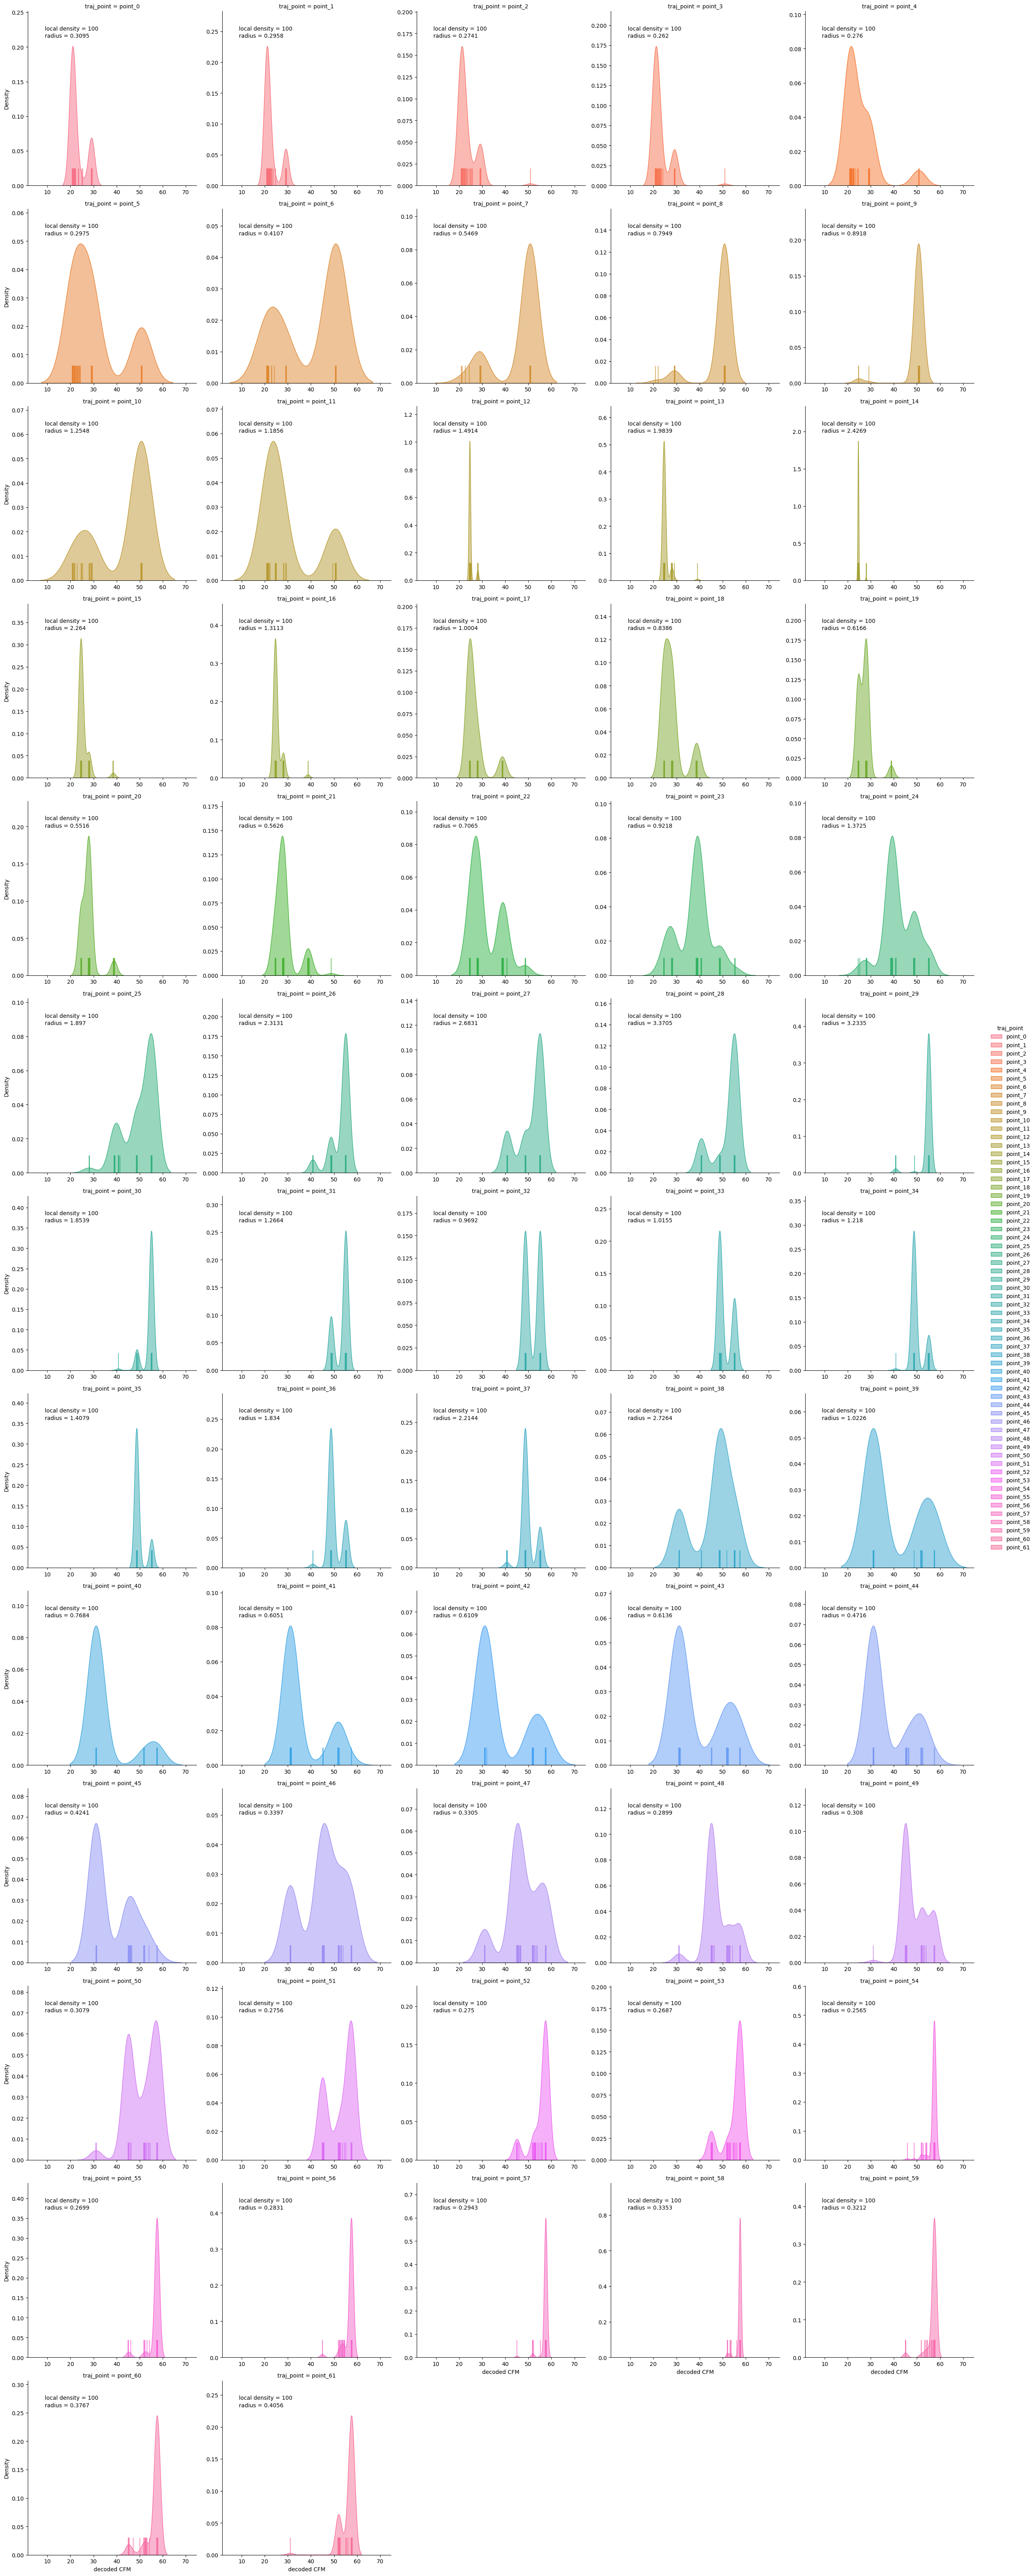

In [106]:
g = sns.displot(data=df_traj_all, x='neighbor_cfm', hue='traj_point', col='traj_point', col_wrap=5, fill=True, kind='kde', alpha=0.5, common_norm=False, bw_adjust=1, rug=True, rug_kws={'height':0.1}, facet_kws={'sharex': True, 'sharey': False})

for i in range(len(traj_info)-1):
    ax = g.axes.flat[i]
    ax.tick_params(labelbottom=True)
    ax.set_xlabel('decoded CFM')
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    df_traj = df_list[i]
    density_value = df_traj.loc[0,'local_density']
    radius_step = round(df_traj.loc[0, 'radius'],4)
    print(xmin)
    print(xmax)
    ax.text(x=xmin+(xmax-xmin)/10, y=ymax-(ymax-ymin)/12, s='local density = ' + str(density_value), horizontalalignment='left', verticalalignment='top', fontsize=10, color='black')
    ax.text(x=xmin+(xmax-xmin)/10, y=ymax-(ymax-ymin)/8, s='radius = ' + str(radius_step), horizontalalignment='left', verticalalignment='top', fontsize=10, color='black')

[Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')]

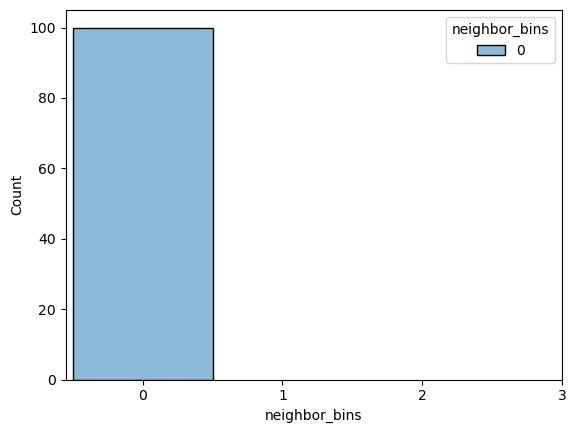

In [107]:
fig, ax = plt.subplots(1,1)
sns.histplot(data=df_list[2], x='neighbor_bins', hue='neighbor_bins', discrete=True, ax=ax)

ax.set_xticks(range(4))
ax.set_xticklabels(range(4))

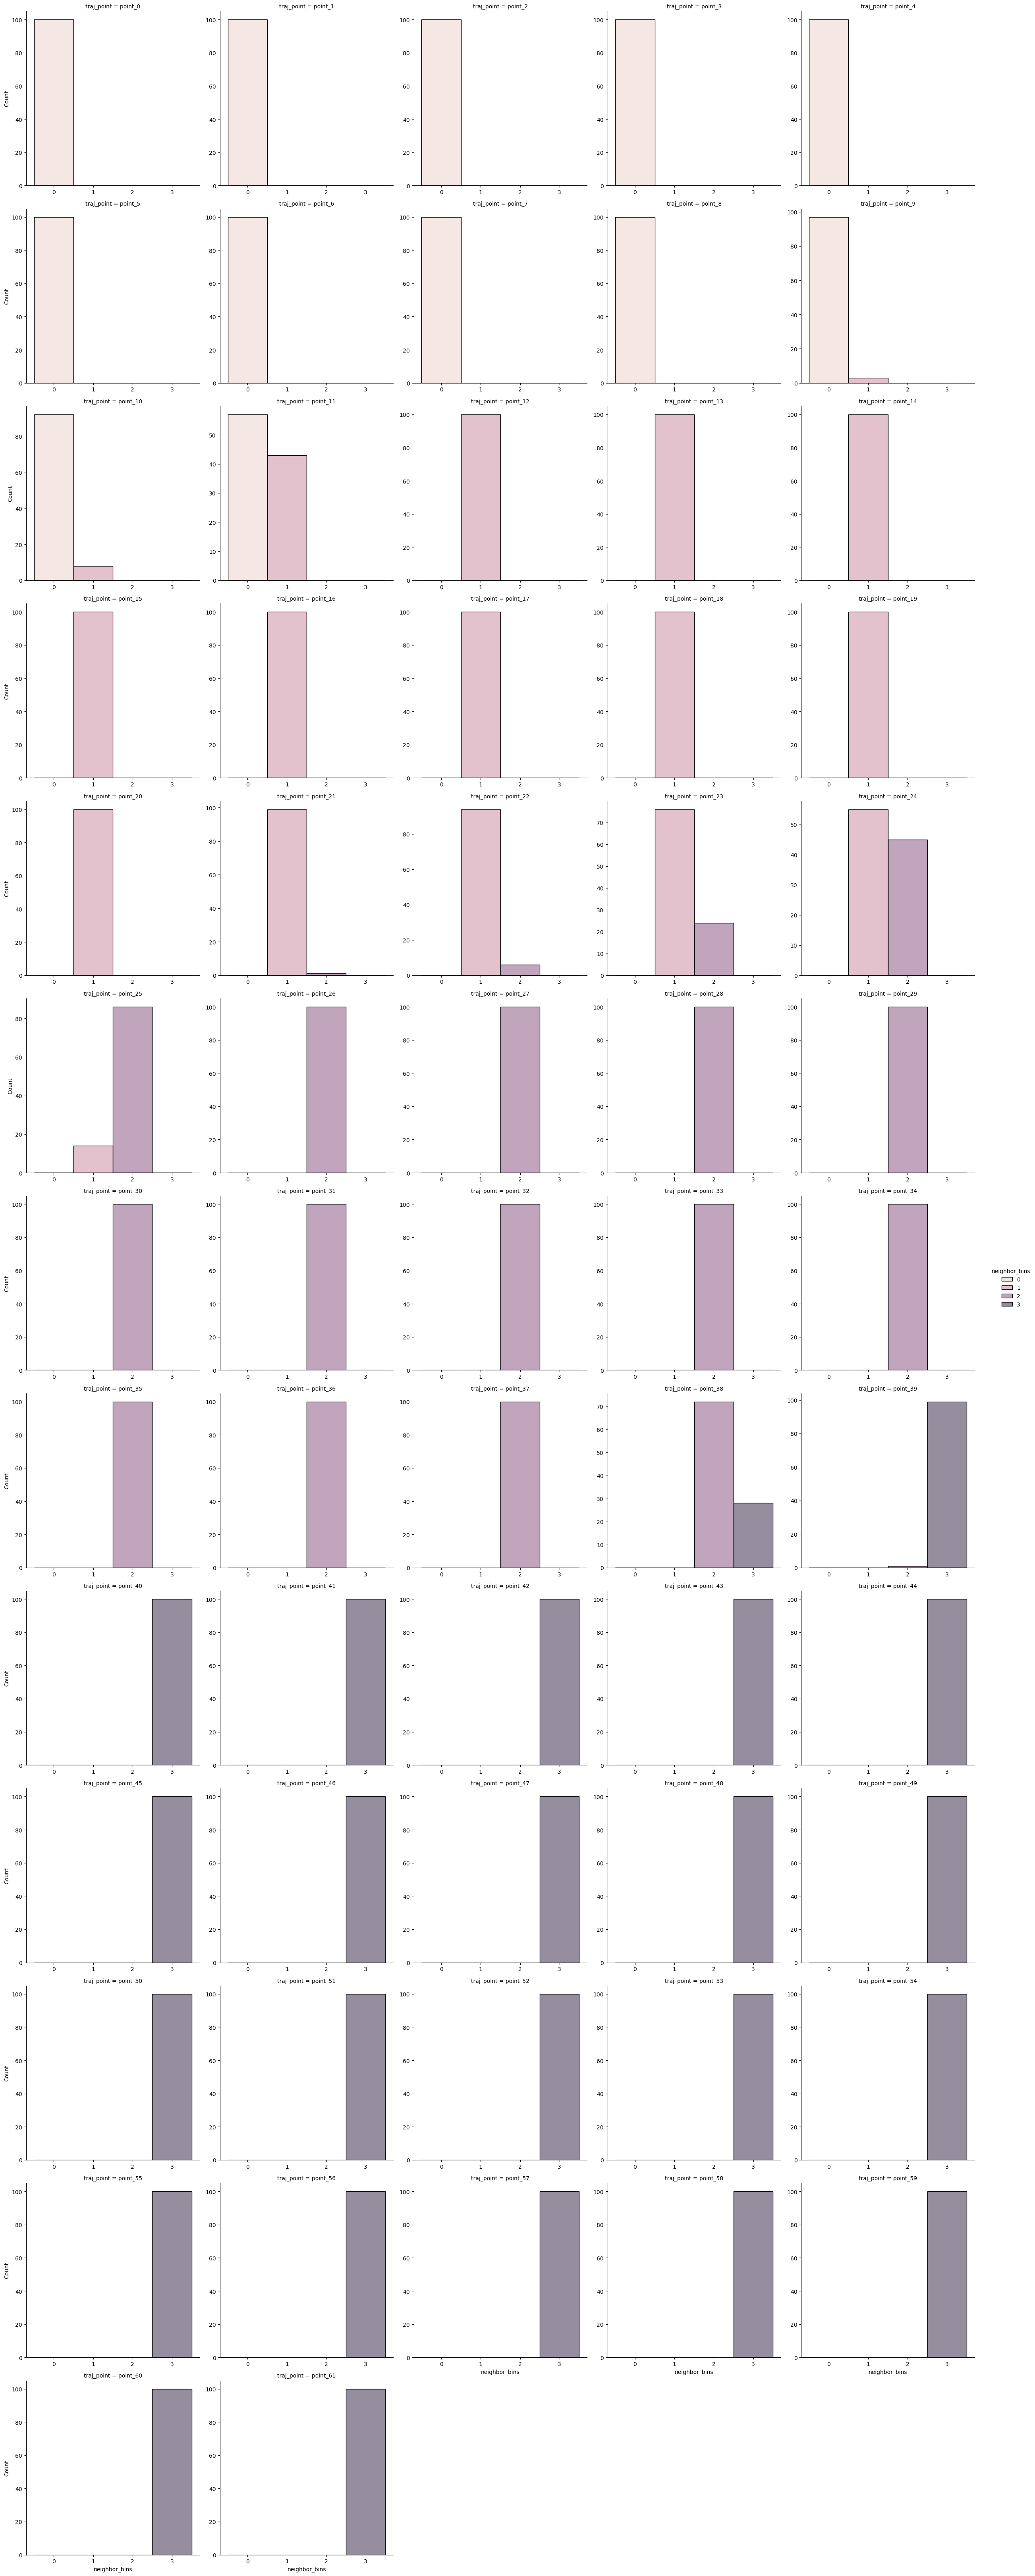

In [108]:
g = sns.displot(data=df_traj_all, x='neighbor_bins', hue='neighbor_bins', col='traj_point', col_wrap=5, fill=True, kind='hist', discrete=True, facet_kws={'sharex': False, 'sharey': False})
g.set(xticks=[0,1,2,3])

In [116]:
df_latent2 = pd.read_csv(Config.LATENT_SPACE_CSV, index_col=0)
df_latent2

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,cell_type,SCBID,MouseID,Age,Strain,Genotype,CFM_14_5_snRNA,14-6-residual,14-6-Bin,region
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,...,Glut,CK19047,1583,14,33,5,1.047481,0.133901,2,PFC
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,...,Gaba,CK19032,1596,14,124,5,1.231932,0.738297,3,PFC
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,...,Astrocytes,CK19107,1583,14,33,5,1.047481,0.383536,2,HC
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,...,glut,CK19119,5696,14,B6,5,-0.825919,1.040817,3,HC
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,...,glut,CK19120,1532,14,65,5,0.708210,-1.314067,0,HC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,...,Oligo,CK19111,1272,14,53,5,0.263749,0.660932,3,PFC
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,...,Gaba,CK19033,1966,14,83,5,-0.974072,-0.989843,0,PFC
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,...,Astrocytes,CK19059,2433,14,113,5,0.550426,-0.111132,2,HC
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,...,glut,CK19078,1596,14,124,5,1.231932,1.277393,3,HC


In [118]:
x_embedded = TSNE(perplexity=30, random_state=22).fit_transform(latent_space)

df_tsne = pd.DataFrame(x_embedded, columns = ['t-SNE 1', 't-SNE 2'])
df_tsne['label'] = df_latent['label']
df_tsne['decoded_cfm'] = df_latent['decoded_cfm']
df_tsne['strain'] = df_latent2['Strain']

Text(0.5, 1.0, 't-SNE compressed latent space')

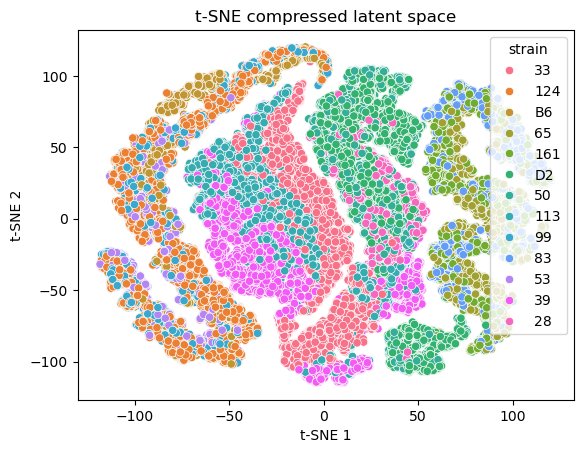

In [125]:
plt.figure()
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', hue='strain', data=df_tsne.iloc[:56651,:])
plt.title('t-SNE compressed latent space')

In [120]:
tsne = oTSNE(
    perplexity=30,
    metric="euclidean",
    n_jobs=8,
    random_state=22,
    verbose=True,
)

embedding_latent_space = tsne.fit(latent_space)

df_otsne = pd.DataFrame(embedding_latent_space, columns = ['t-SNE 1', 't-SNE 2'])
df_otsne['label'] = df_latent['label']
df_otsne['decoded_cfm'] = df_latent['decoded_cfm']
df_otsne['strain'] = df_latent2['Strain']

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=8, random_state=22, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 2.28 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.35 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=12.00, lr=4720.83 for 250 iterations...
Iteration   50, KL divergence 5.2331, 50 iterations in 0.6649 sec
Iteration  100, KL divergence 4.6234, 50 iterations in 0.6812 sec
Iteration  150, KL divergence 4.3193, 50 iterations in 0.6806 sec
Iteration  200, KL divergence 4.1674, 50 iterations in 0.6568 sec
Iteration  250, KL divergence 4.0758, 50 iterations in 0.6331 sec
   --> Time elapsed: 3.32 seconds
===> Running optimization with exaggeration=1

Text(0.5, 1.0, 'oTSNE compressed latent space')

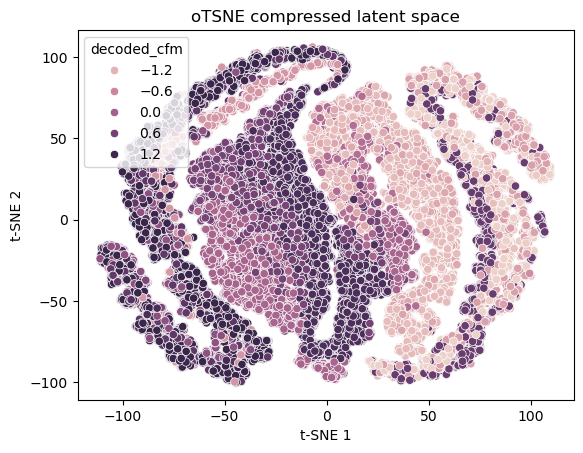

In [124]:
plt.figure()
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', hue='decoded_cfm', data=df_otsne)
plt.title('oTSNE compressed latent space')

In [128]:
df_gene

,0,1,2,3,4,5,6,7,8,9,...,cell_type,SCBID,MouseID,Age,Strain,Genotype,CFM_14_5_snRNA,14-6-residual,14-6-Bin,region
0,0.651218,-1.021155,-1.377396,-0.259220,-0.771110,-0.722307,-0.492144,-2.271440,0.010342,-3.038462,...,Astrocytes,CK19012,1576,14,D2,5,24.44,-0.673075,1,HC
1,-0.073969,1.044795,0.148491,-0.039973,-0.498632,0.130873,-0.371703,0.602898,-0.133319,-1.773600,...,Astrocytes,CK19012,1576,14,D2,5,24.44,-0.673075,1,HC
2,0.130587,0.679869,-0.500390,1.875786,-0.164559,0.716544,0.088206,-0.932251,-0.220543,-0.642520,...,Astrocytes,CK19012,1576,14,D2,5,24.44,-0.673075,1,HC
3,-0.942050,0.661894,-0.084590,0.747387,1.270573,-0.309705,0.173709,-0.398908,0.379914,-0.943867,...,Astrocytes,CK19012,1576,14,D2,5,24.44,-0.673075,1,HC
4,0.309103,-1.060622,-2.314545,-0.323853,1.100788,0.739255,0.384902,-1.108612,0.442371,-0.462451,...,Astrocytes,CK19012,1576,14,D2,5,24.44,-0.673075,1,HC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-1.906910,0.062477,-1.664380,1.833412,2.859790,0.510028,1.813876,-2.427323,3.465779,0.872791,...,Oligo,CK19063,2433,14,113,5,49.96,-0.148236,2,PFC
56646,0.606888,-0.423059,-0.399247,0.495088,0.324318,-0.752585,0.016553,-1.009676,0.259948,0.146926,...,Oligo,CK19063,2433,14,113,5,49.96,-0.148236,2,PFC
56647,0.461220,0.036926,-0.009645,-0.192181,0.510577,0.165473,0.283715,-0.025782,-0.237530,0.121473,...,Oligo,CK19063,2433,14,113,5,49.96,-0.148236,2,PFC
56648,1.103650,-0.076387,-0.185525,0.135558,0.830014,-0.276464,0.363134,-0.811895,0.478318,0.624073,...,Oligo,CK19063,2433,14,113,5,49.96,-0.148236,2,PFC
